<a href="https://colab.research.google.com/github/ImamSohelHosaain/ABEM-terrameter-LS2-Reciprocal-Array/blob/main/Copy_of_ERT_EDA_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Promt
I have 600 m length ERT profile data having 120 m depth data which I got after inversion in RES2D inv software and the data contains x locations, depth and resistivity data. How can I use these data for statistical test to strengthen my findings? Which statistical test or analysis should I do? provide me insights. Normally I get an image or use it for surfer plot after export


# Data from RES2D inversion .dat format.
We got location, elevation and resistivity data from Res2DInv and then copy and paste into excel sheet.



# Focus-Data Driven Interpretation of ERT Profiles

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional (nicer plots)
import seaborn as sns
sns.set(style="whitegrid")

In [3]:
file_path = "/content/santosh01.xlsx"   # change this always

df = pd.read_excel(file_path)

# Rename columns for convenience
df.columns = ["X", "Depth", "Resistivity"]

print(df.head())
print(df.info())

      X  Depth  Resistivity
0   2.5 -0.938        57.48
1   7.5 -0.938        57.48
2  12.5 -0.938        57.48
3  17.5 -0.938        57.48
4  22.5 -0.938        57.48
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   X            2772 non-null   float64
 1   Depth        2772 non-null   float64
 2   Resistivity  2772 non-null   float64
dtypes: float64(3)
memory usage: 65.1 KB
None


In [4]:
# Convert depth to positive
df["Depth"] = df["Depth"].abs()

# Remove zero/negative resistivity
df = df[df["Resistivity"] > 0]

# Log transform
df["LogRes"] = np.log10(df["Resistivity"])

# Sort data (important for profiles)
df = df.sort_values(by=["X", "Depth"])

print(df.describe())

                 X        Depth    Resistivity       LogRes
count  2772.000000  2772.000000    2772.000000  2772.000000
mean    315.000000    45.147591     783.285543     2.003918
std     181.892419    37.322905    4920.424432     0.912521
min       2.500000     0.938000       0.033000    -1.481486
25%     157.500000    12.957000      24.911000     1.396391
50%     315.000000    34.868000      98.273000     1.992434
75%     472.500000    71.714000     385.401750     2.585914
max     627.500000   126.943000  243450.047000     5.386410


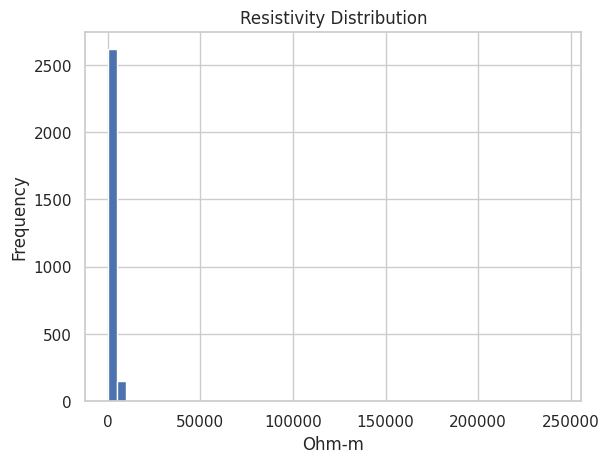

In [5]:
plt.figure()
plt.hist(df["Resistivity"], bins=50)
plt.title("Resistivity Distribution")
plt.xlabel("Ohm-m")
plt.ylabel("Frequency")
plt.show()

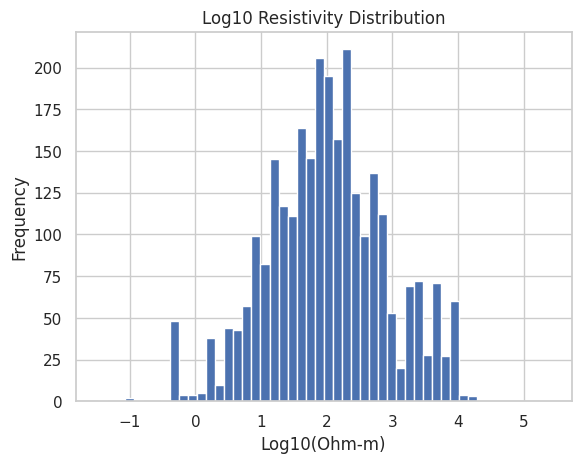

In [6]:
plt.figure()
plt.hist(df["LogRes"], bins=50)
plt.title("Log10 Resistivity Distribution")
plt.xlabel("Log10(Ohm-m)")
plt.ylabel("Frequency")
plt.show()

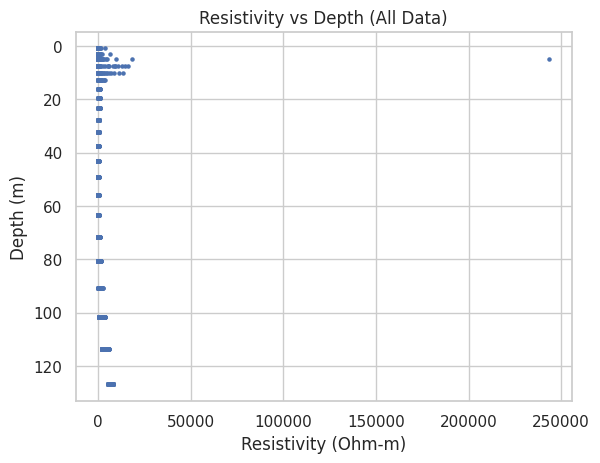

In [7]:
plt.figure()
plt.scatter(df["Resistivity"], df["Depth"], s=5)
plt.gca().invert_yaxis()
plt.xlabel("Resistivity (Ohm-m)")
plt.ylabel("Depth (m)")
plt.title("Resistivity vs Depth (All Data)")
plt.show()

In [8]:
grouped = df.groupby("X")

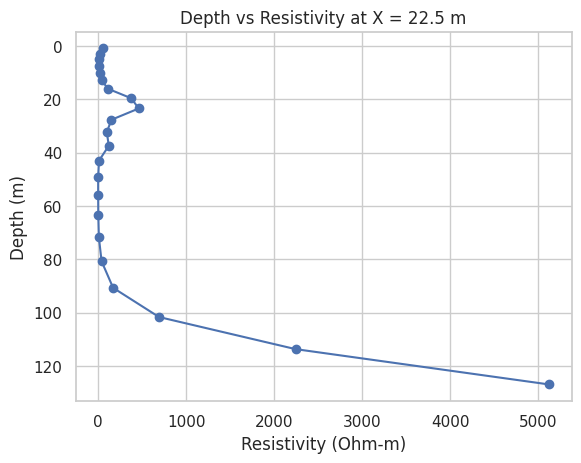

In [9]:
x_val = 22.5   # change any value

profile = df[df["X"] == x_val]

plt.figure()
plt.plot(profile["Resistivity"], profile["Depth"], marker='o')
plt.gca().invert_yaxis()
plt.xlabel("Resistivity (Ohm-m)")
plt.ylabel("Depth (m)")
plt.title(f"Depth vs Resistivity at X = {x_val} m")
plt.show()

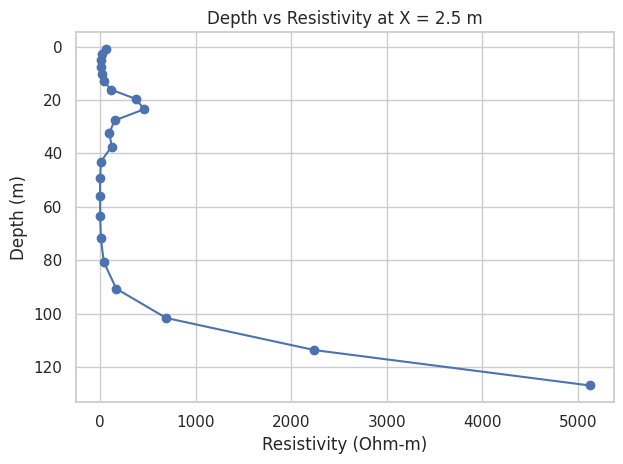

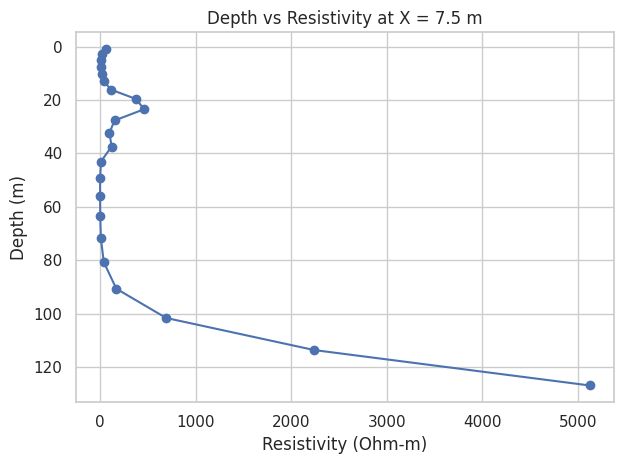

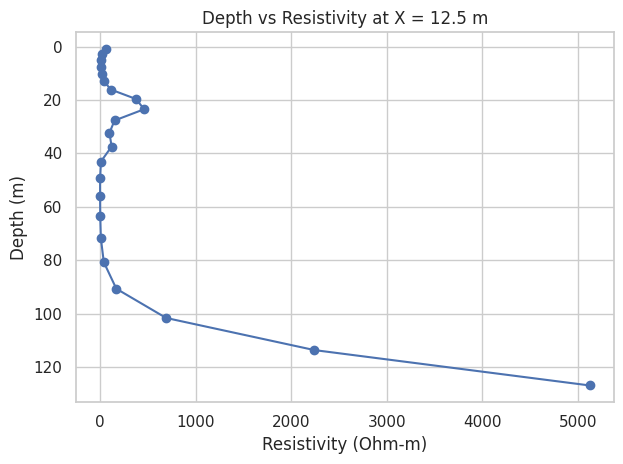

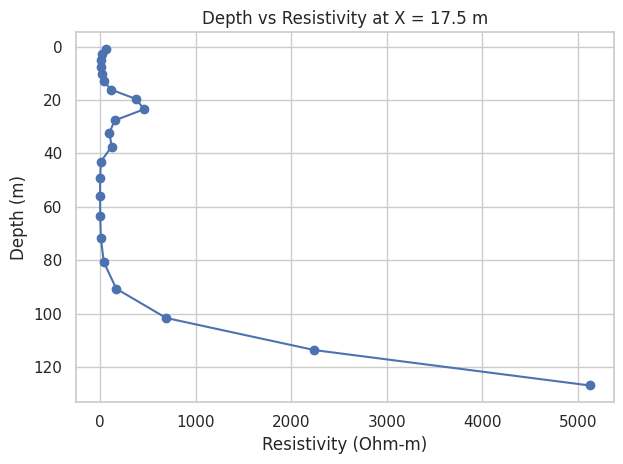

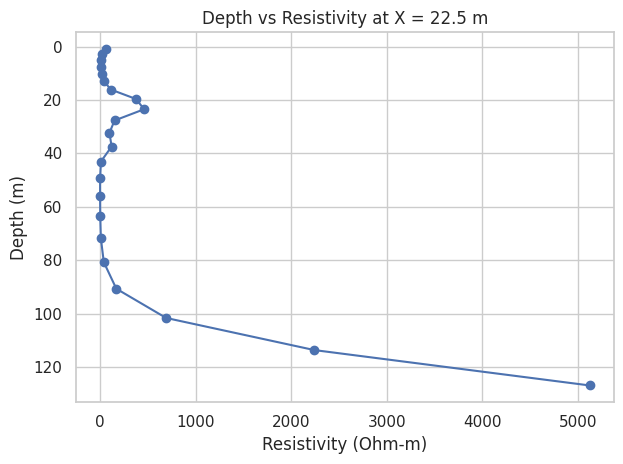

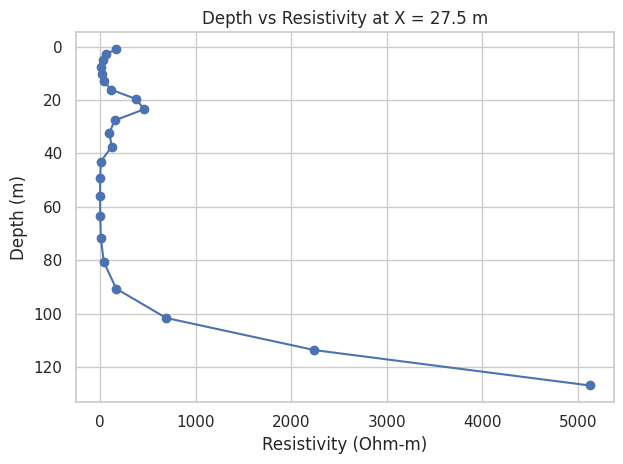

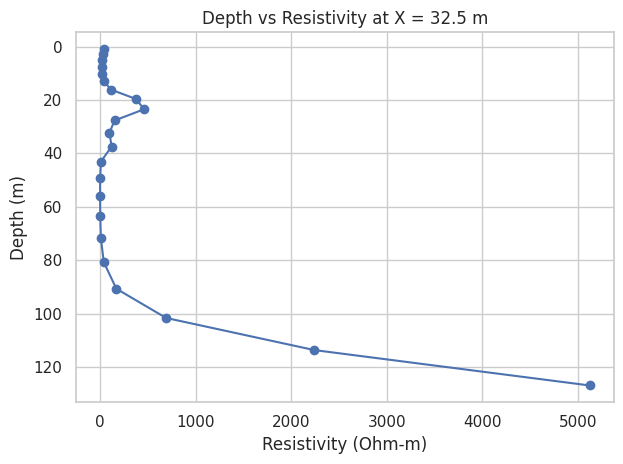

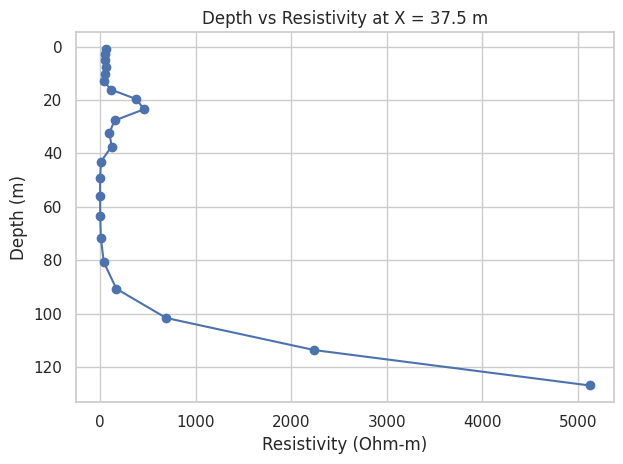

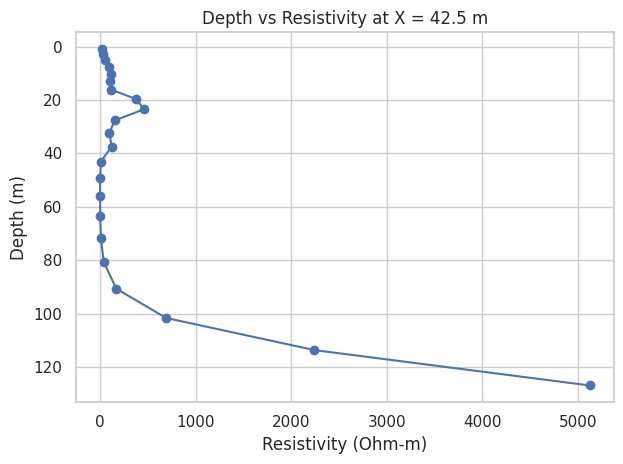

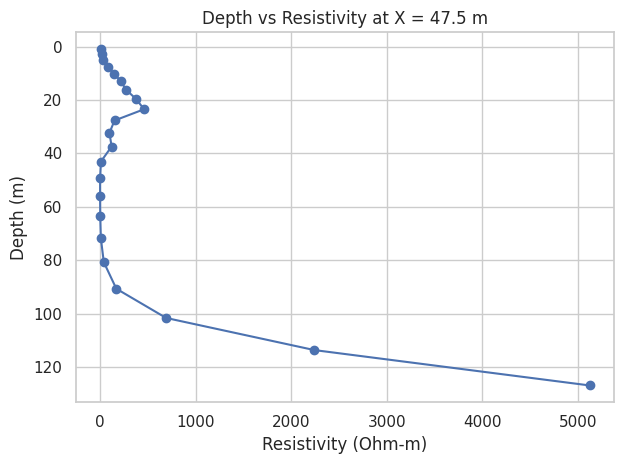

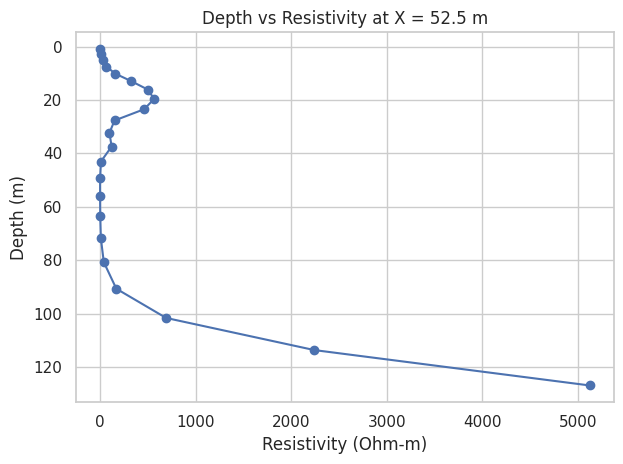

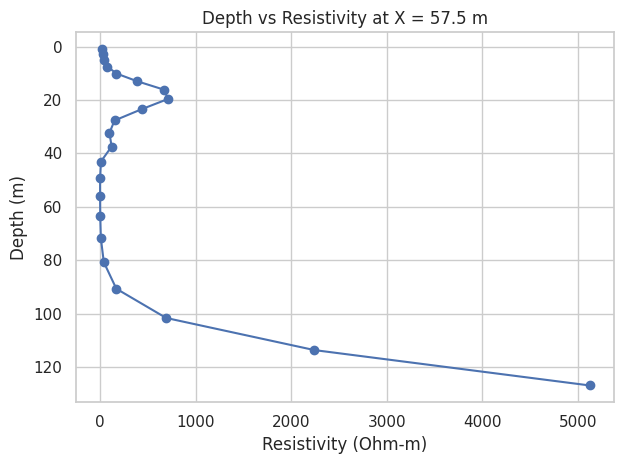

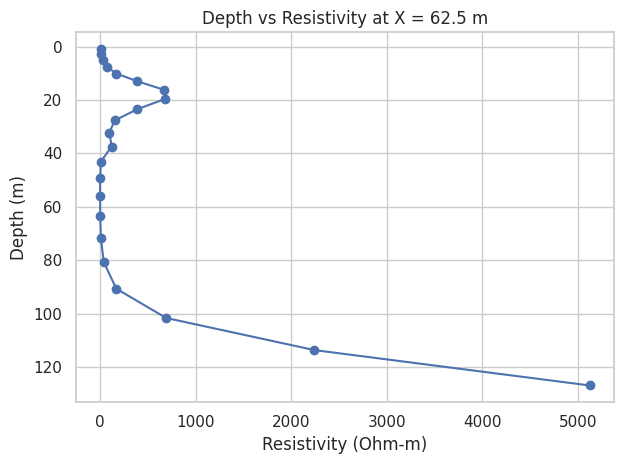

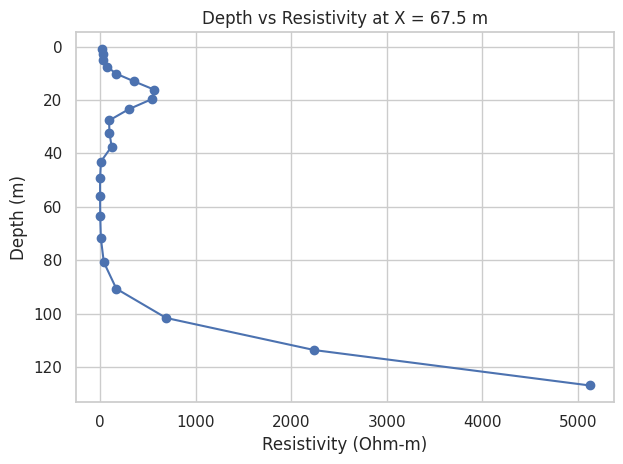

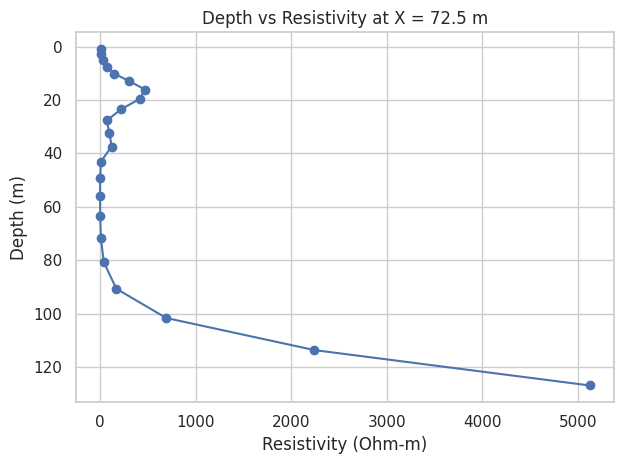

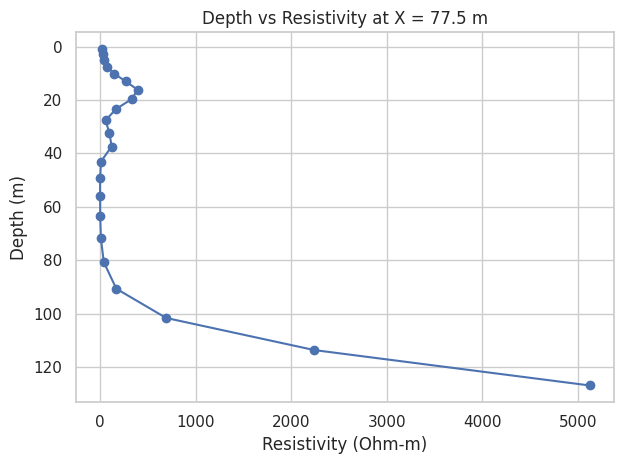

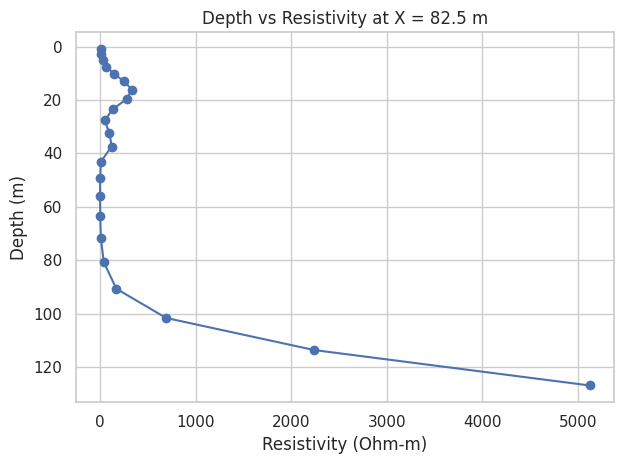

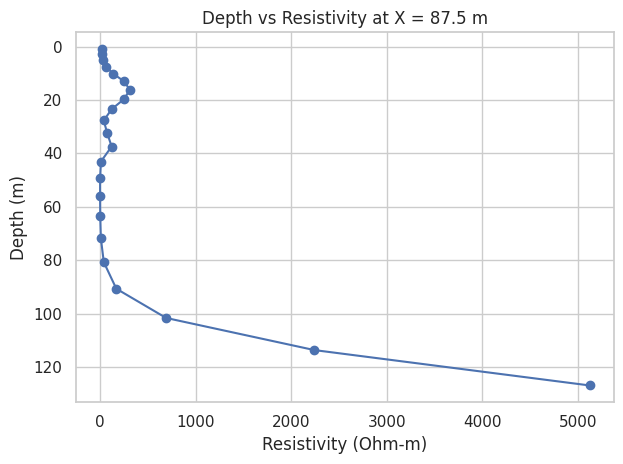

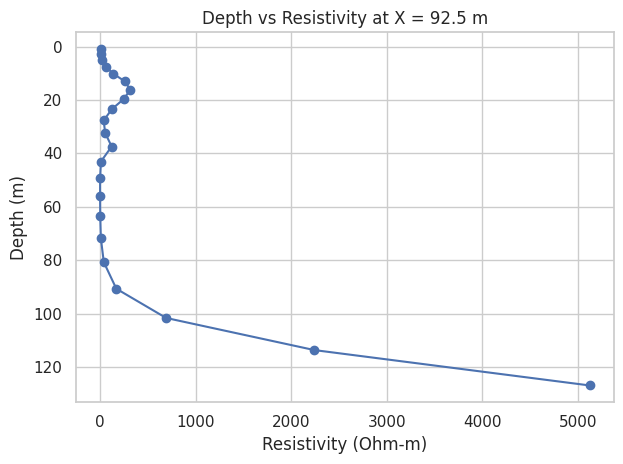

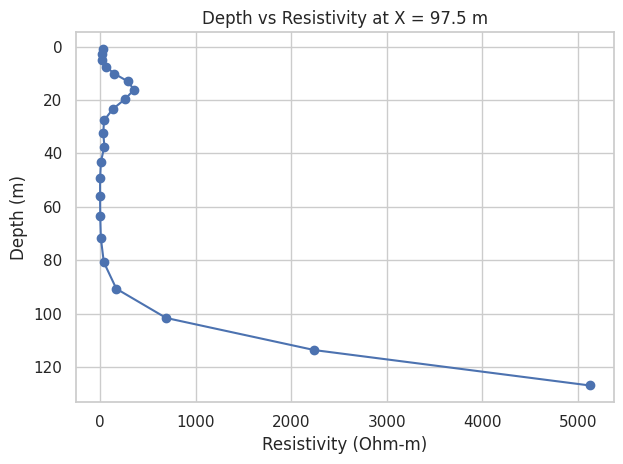

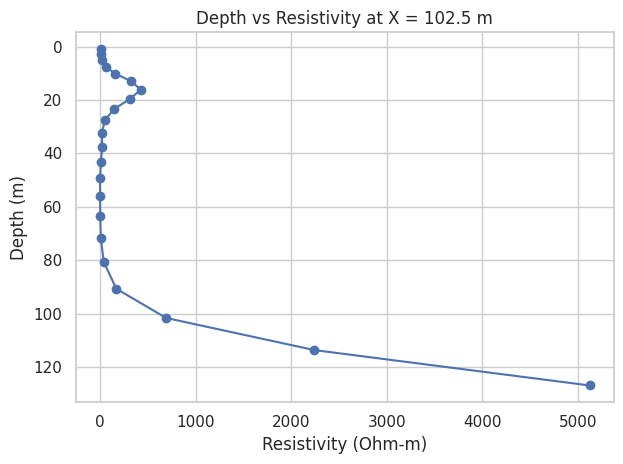

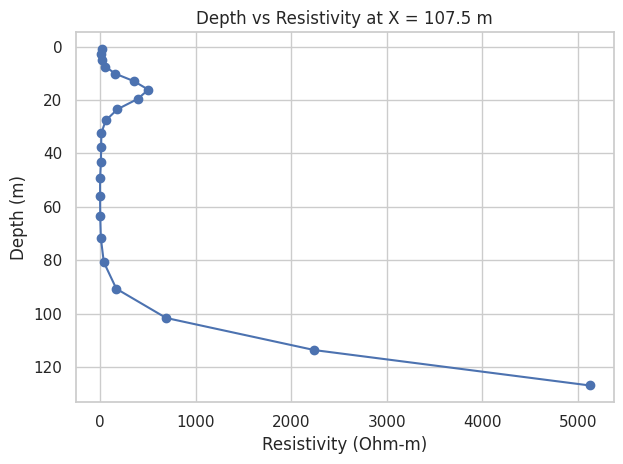

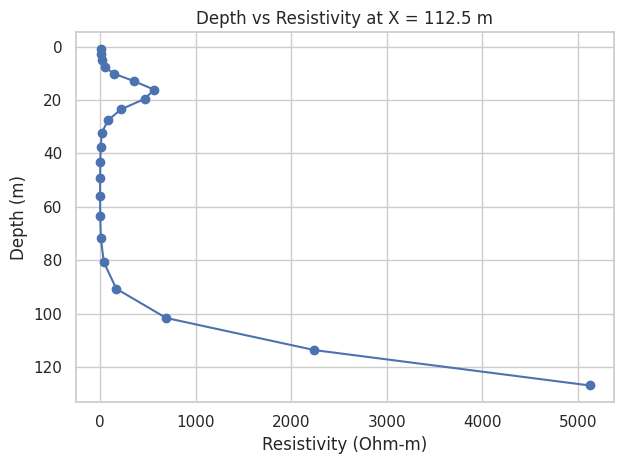

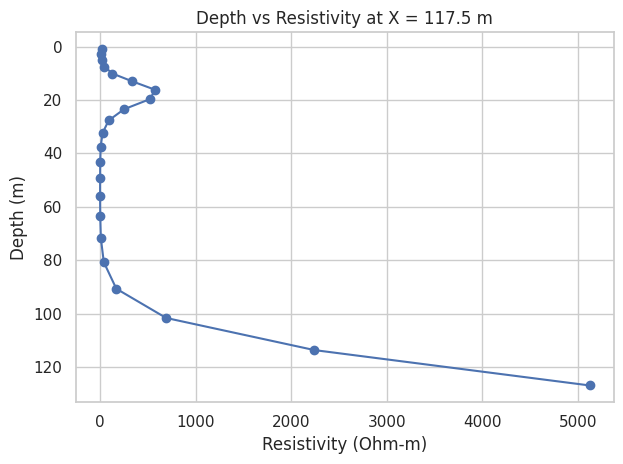

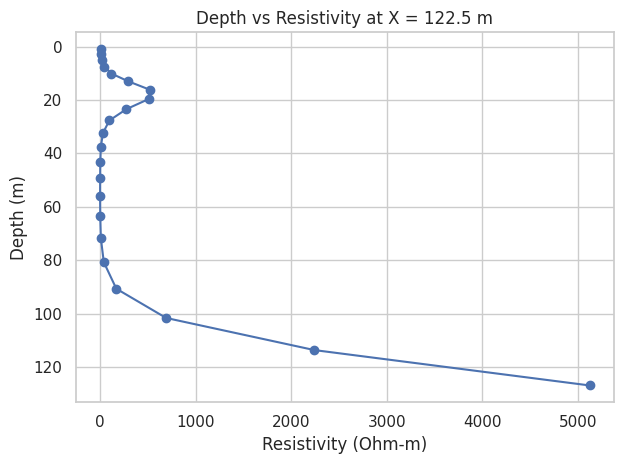

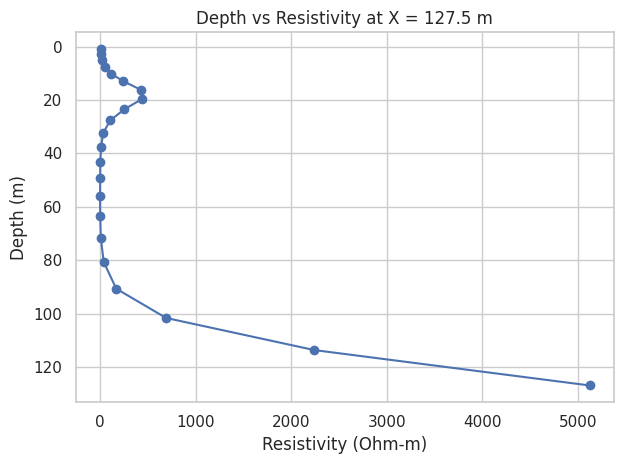

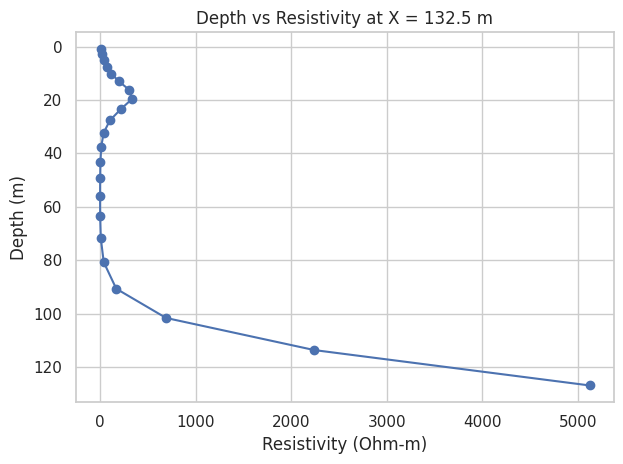

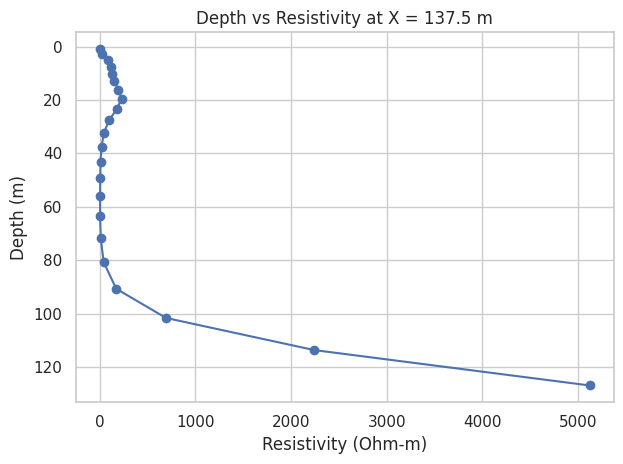

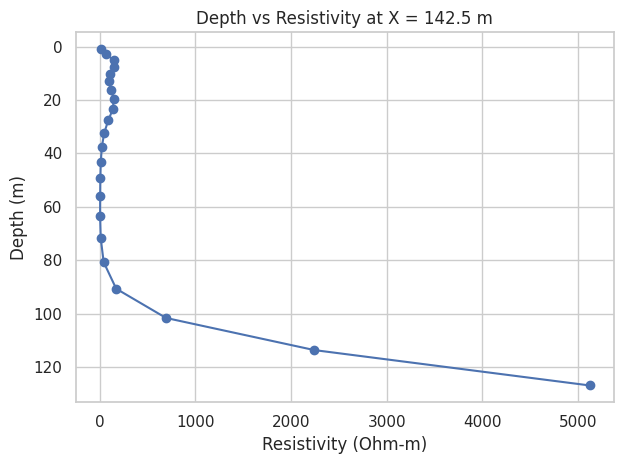

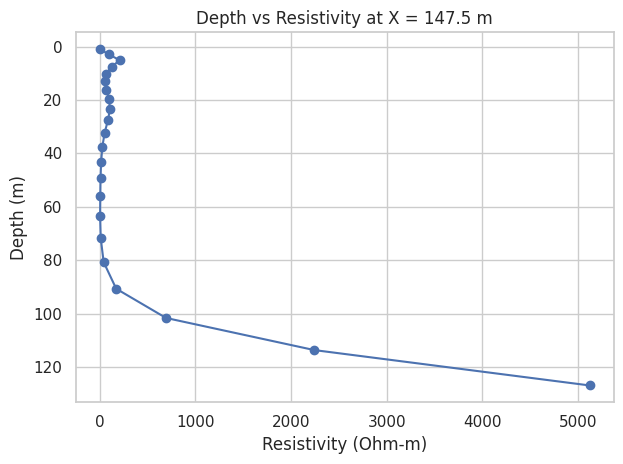

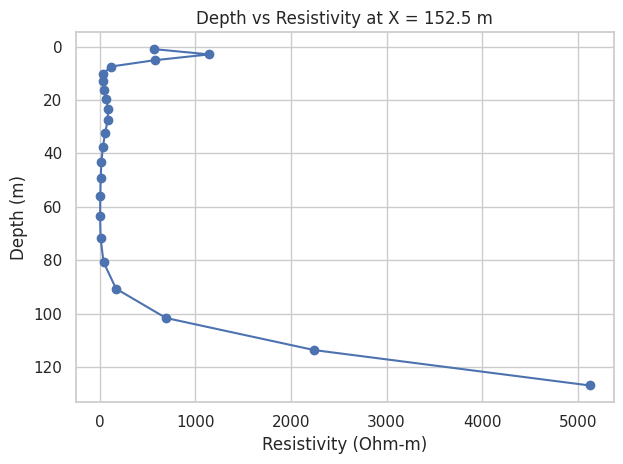

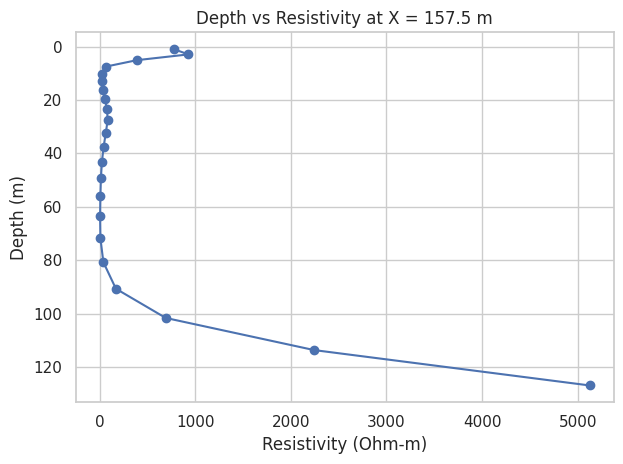

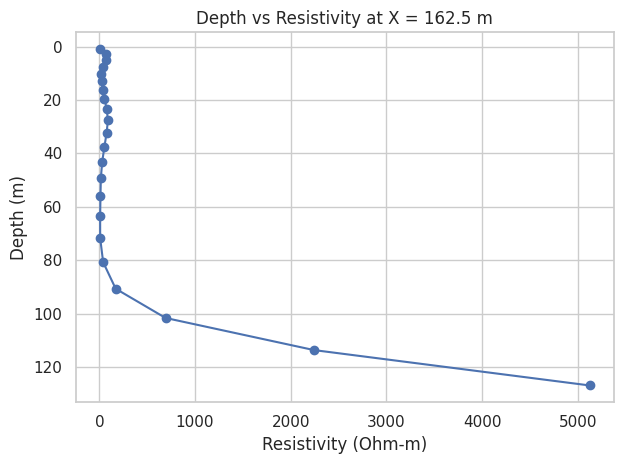

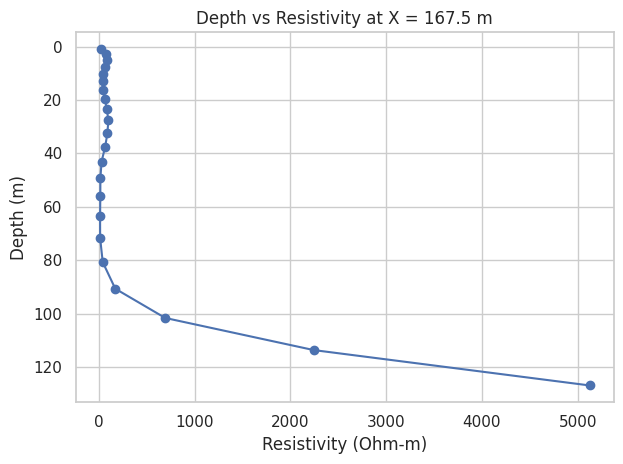

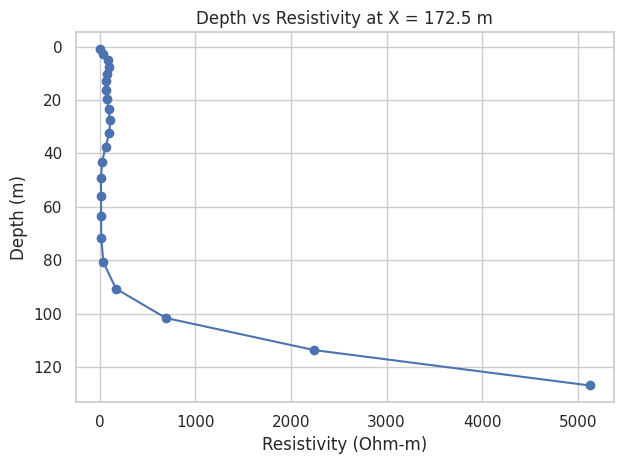

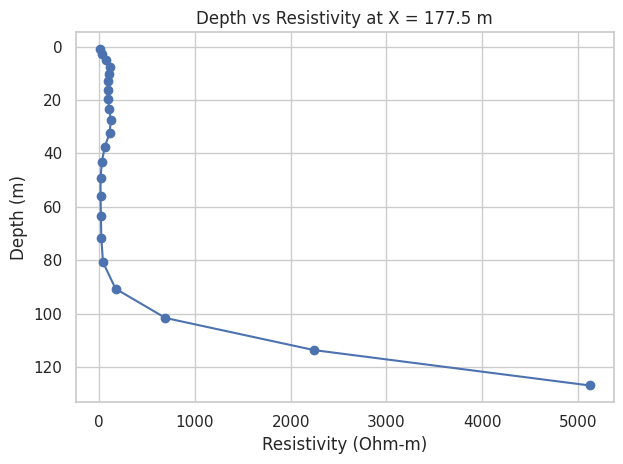

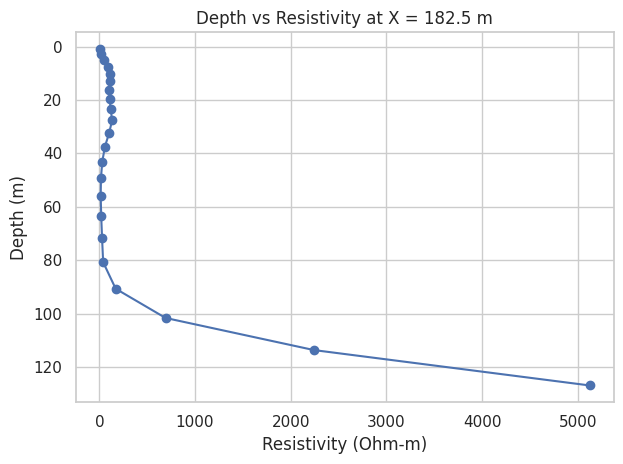

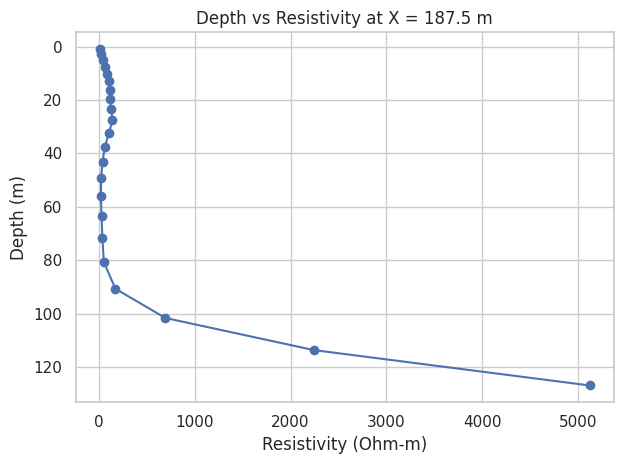

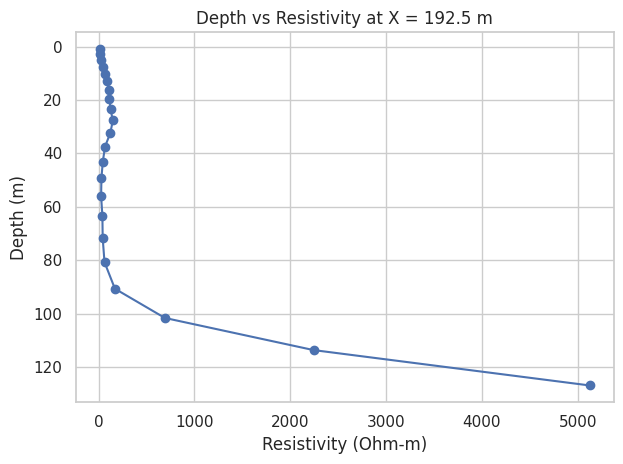

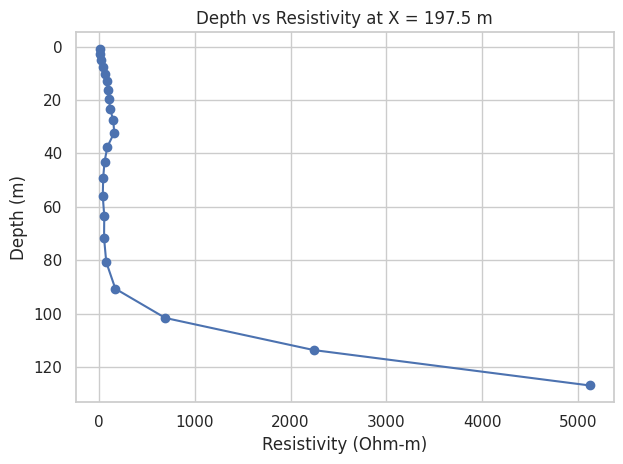

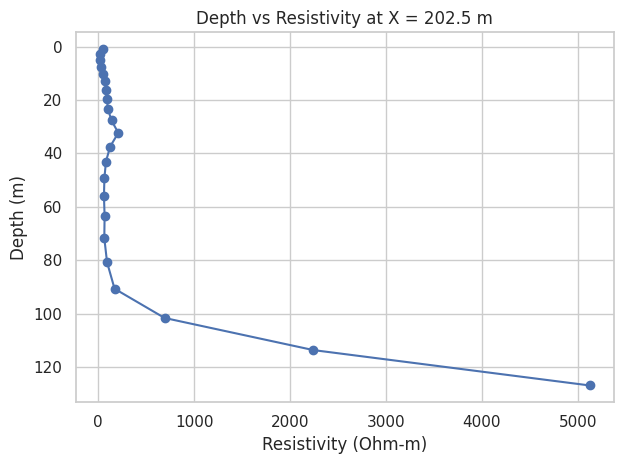

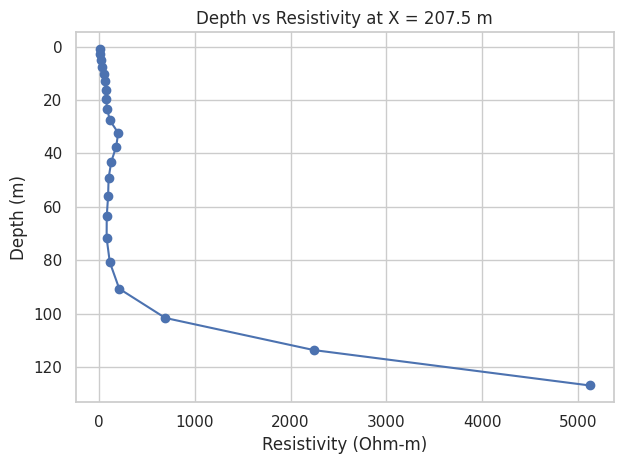

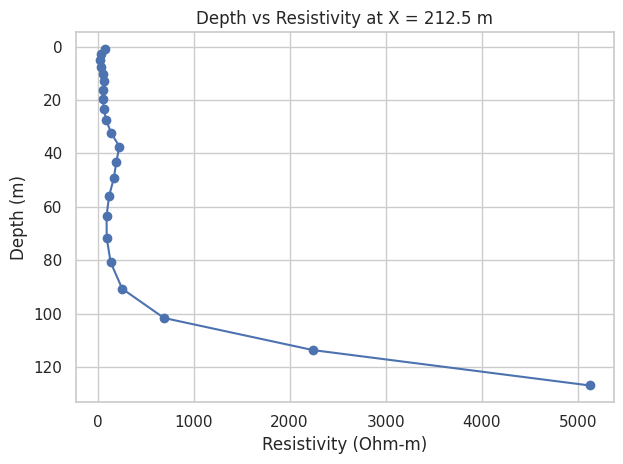

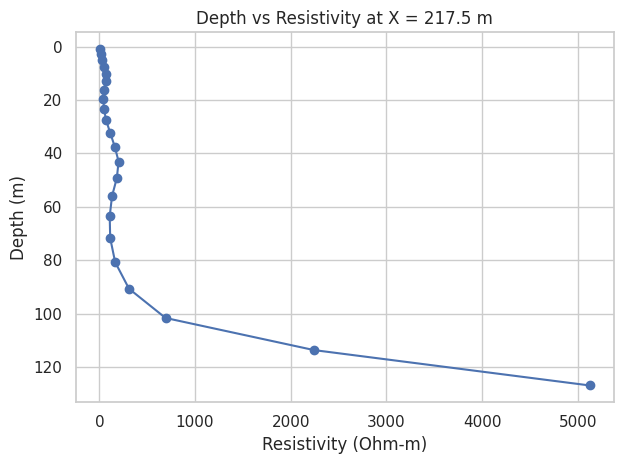

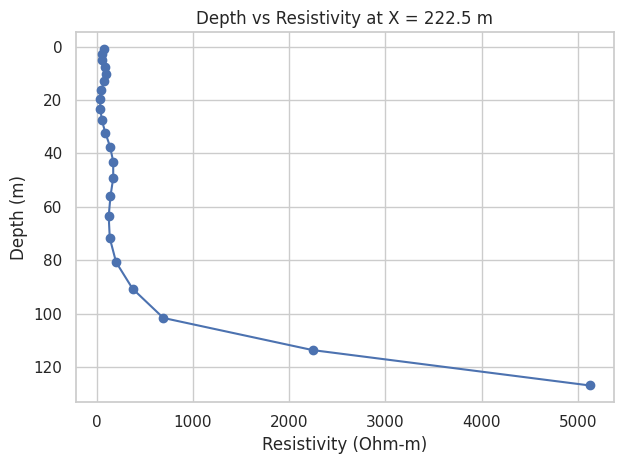

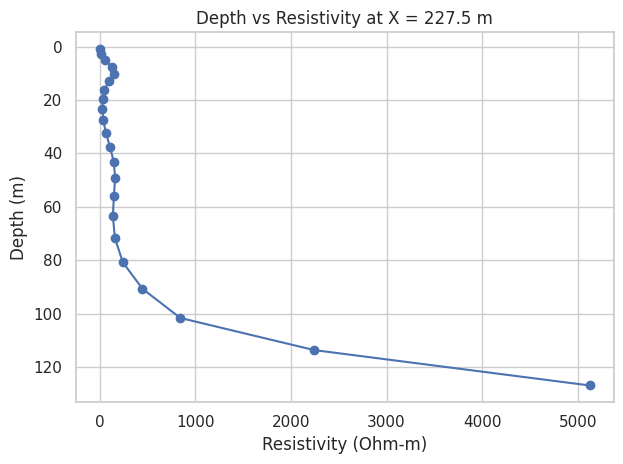

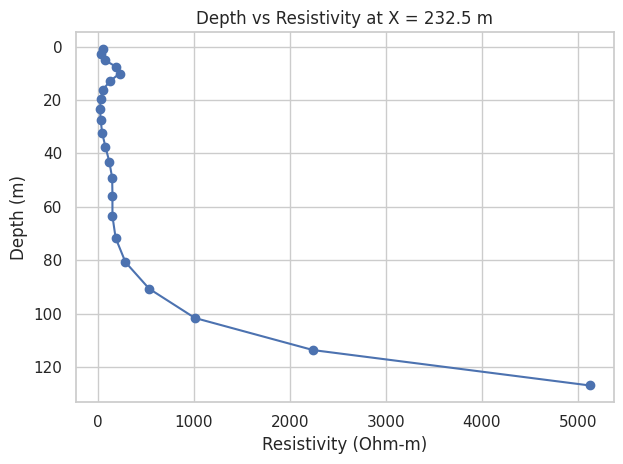

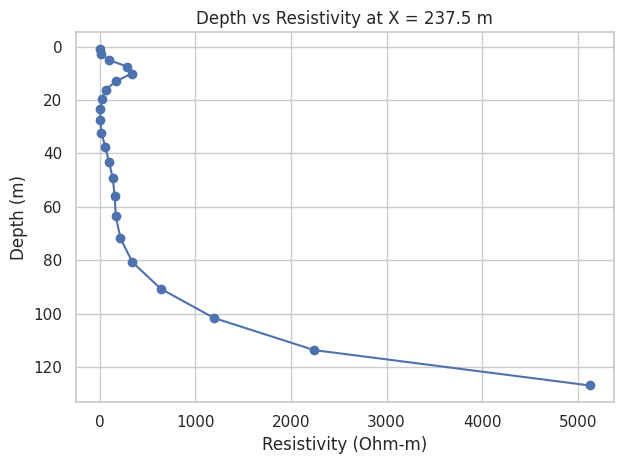

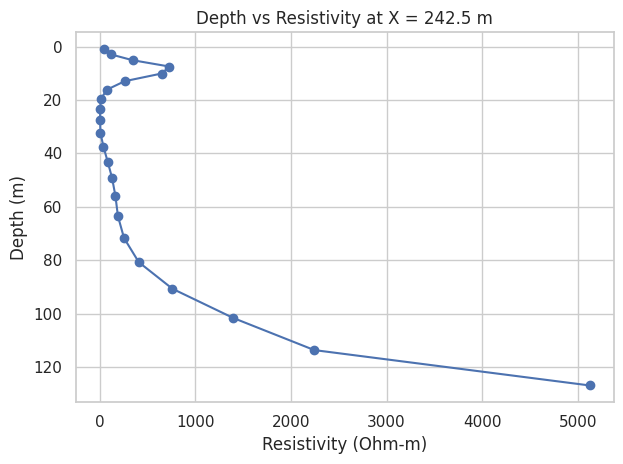

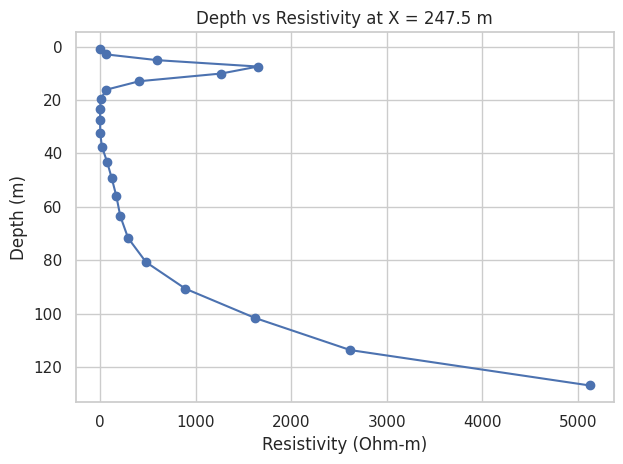

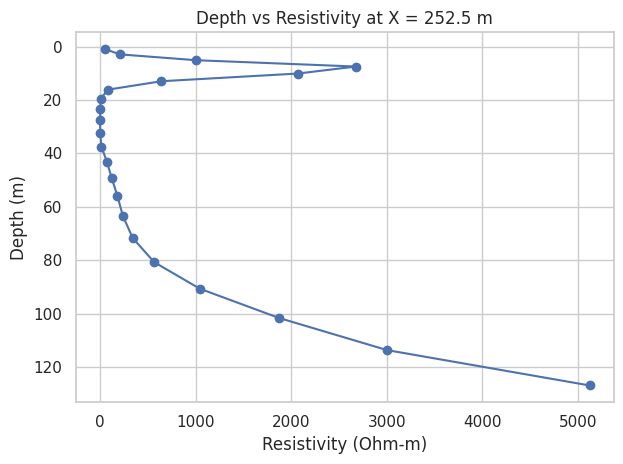

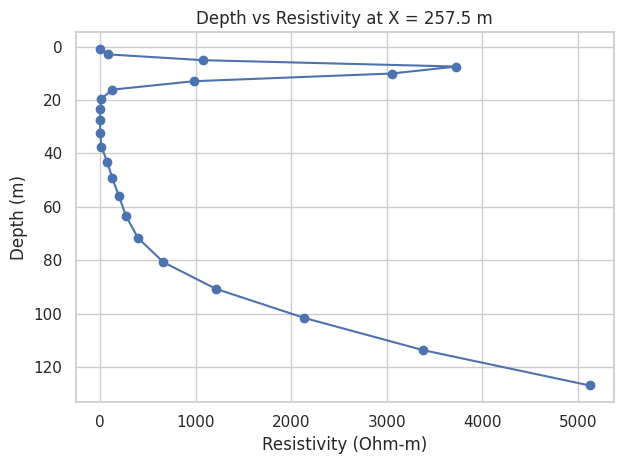

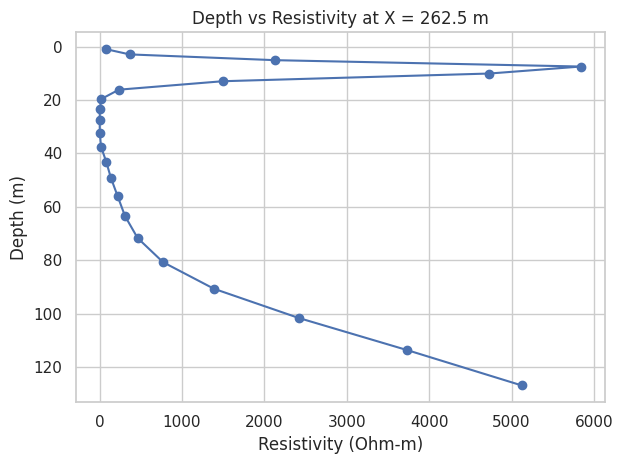

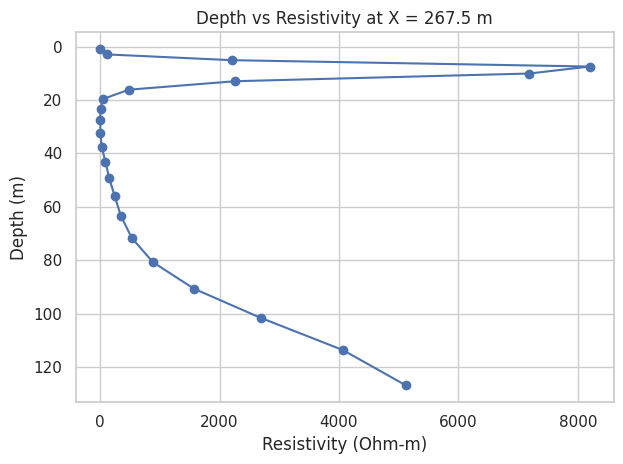

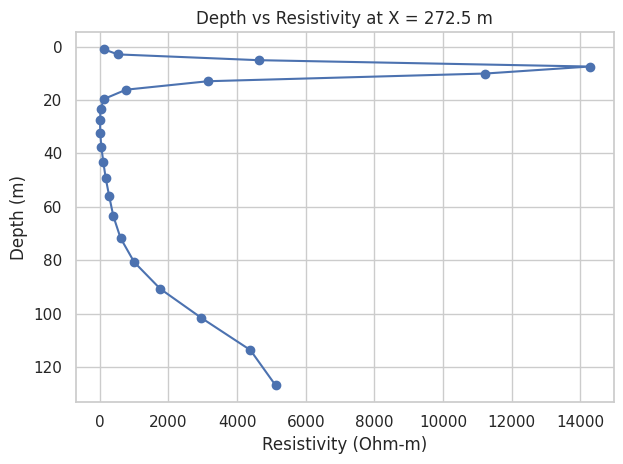

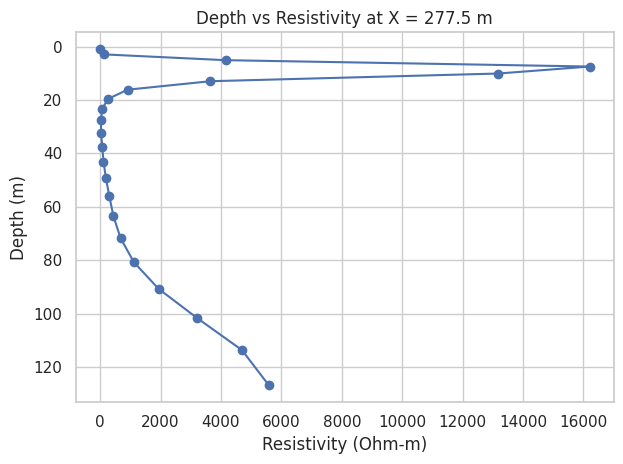

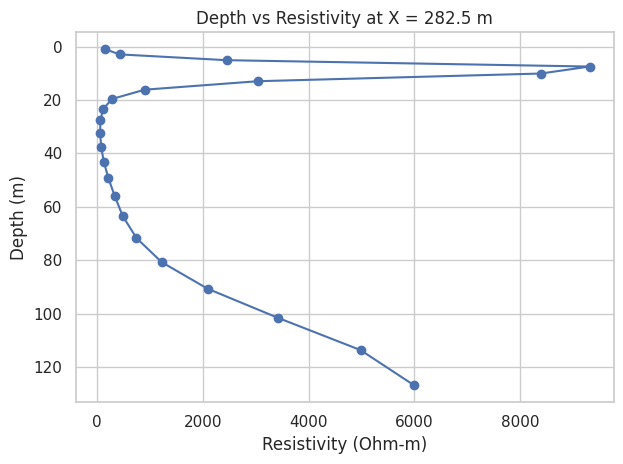

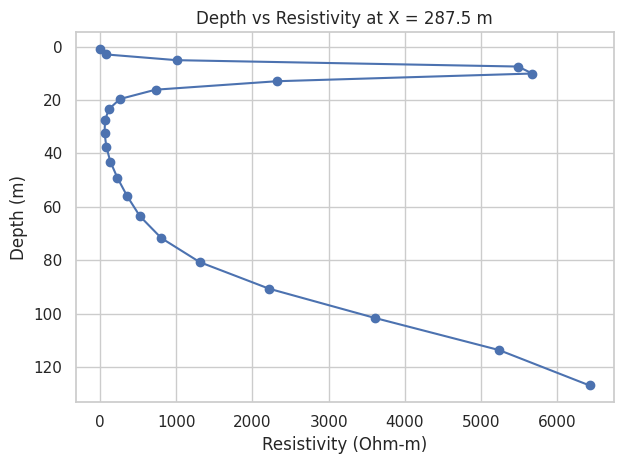

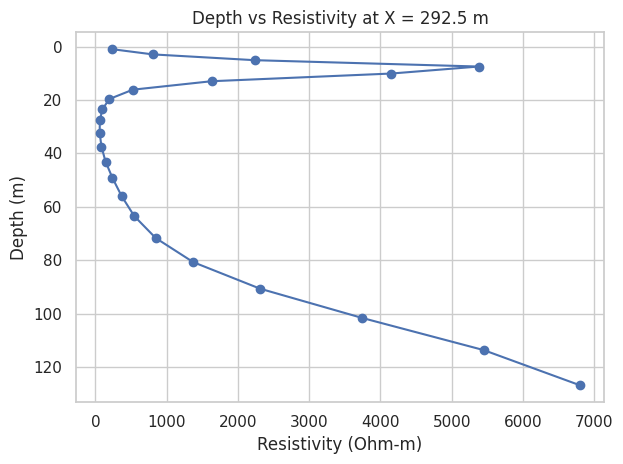

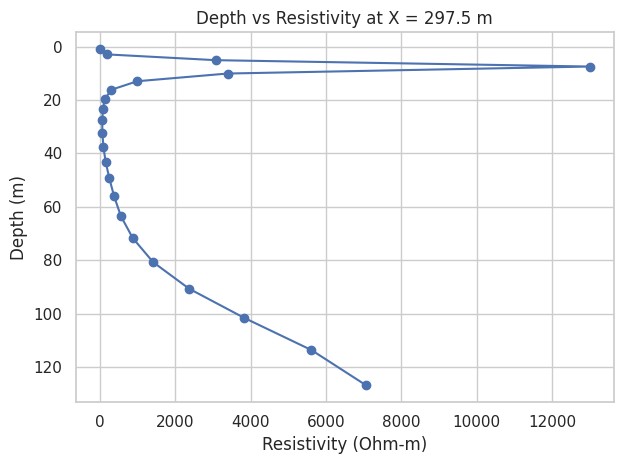

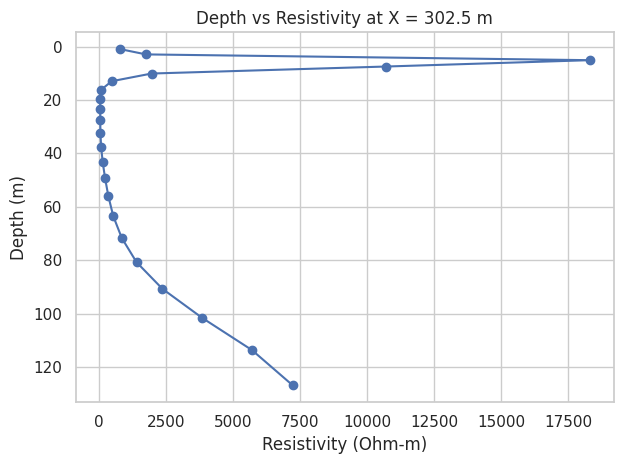

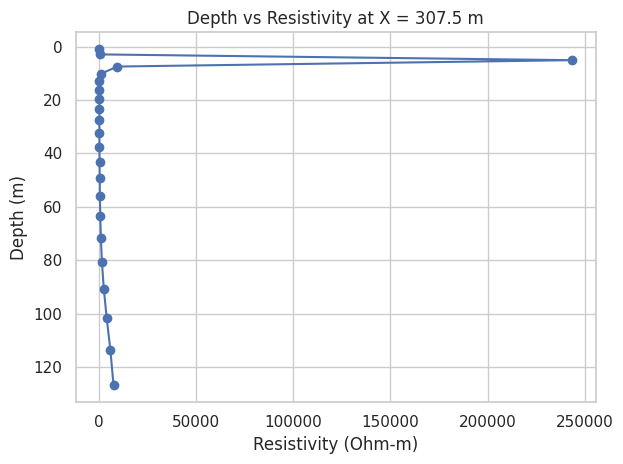

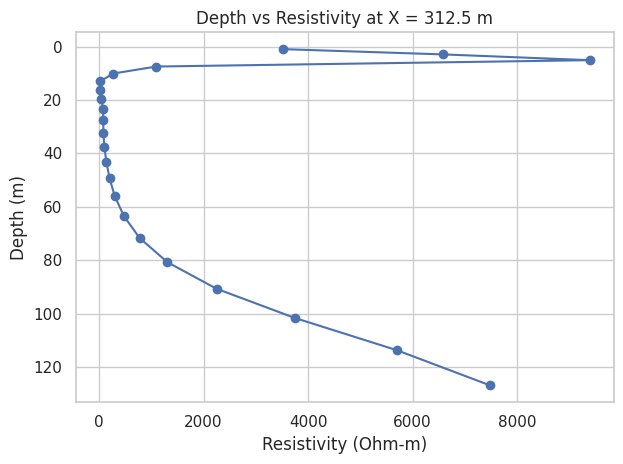

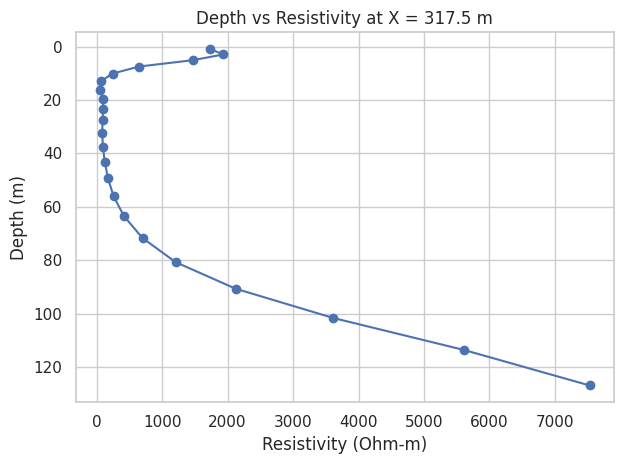

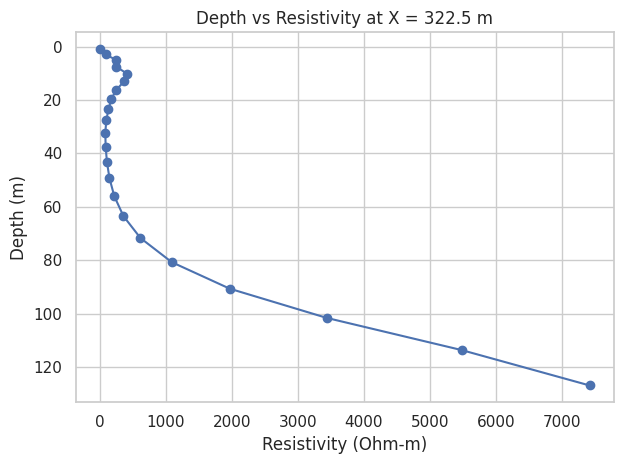

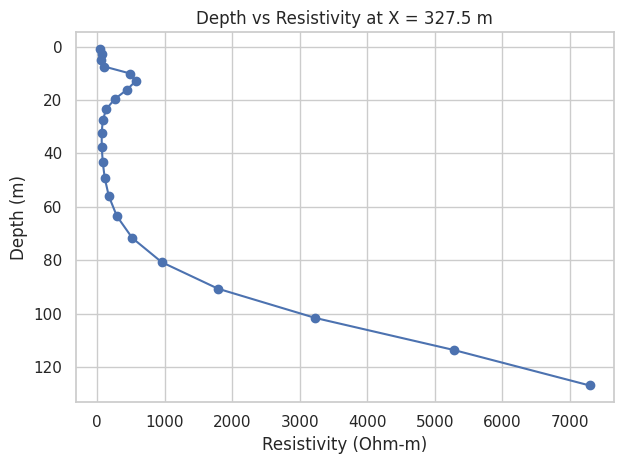

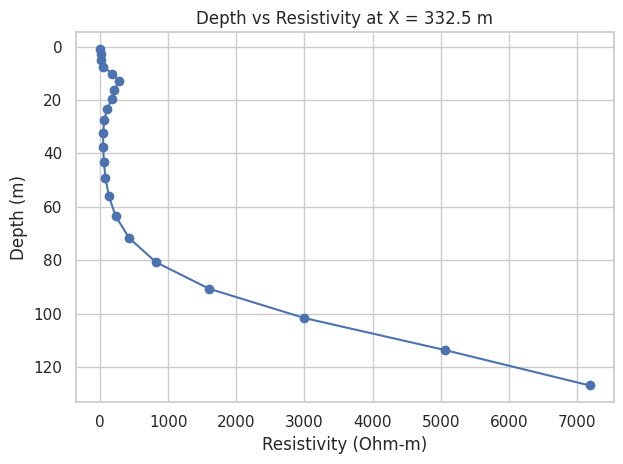

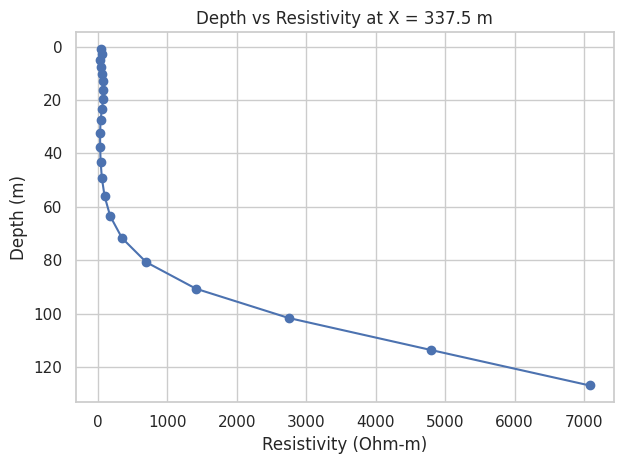

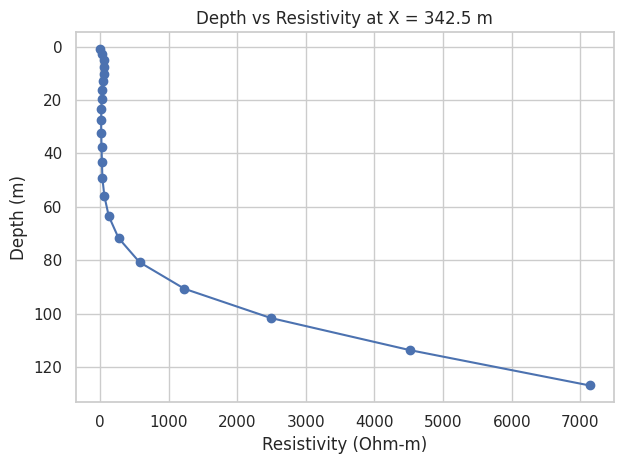

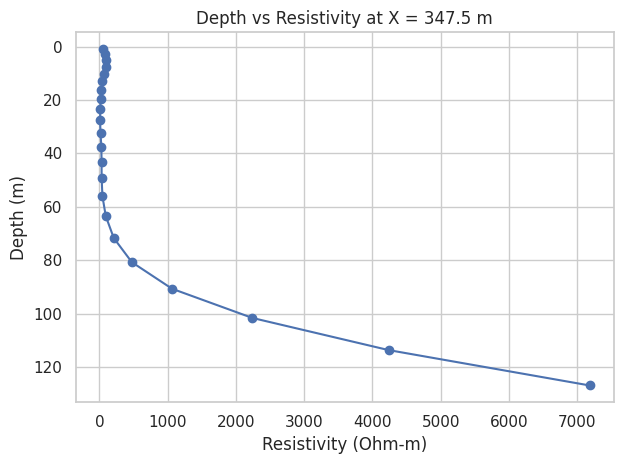

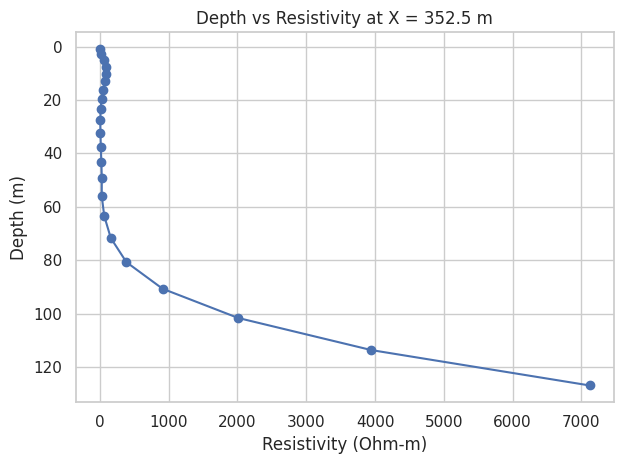

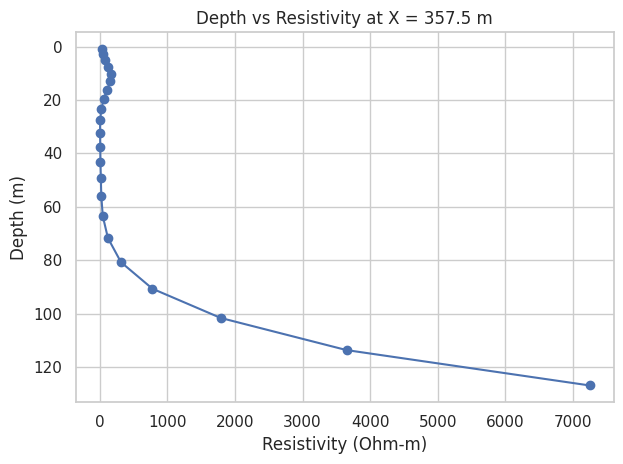

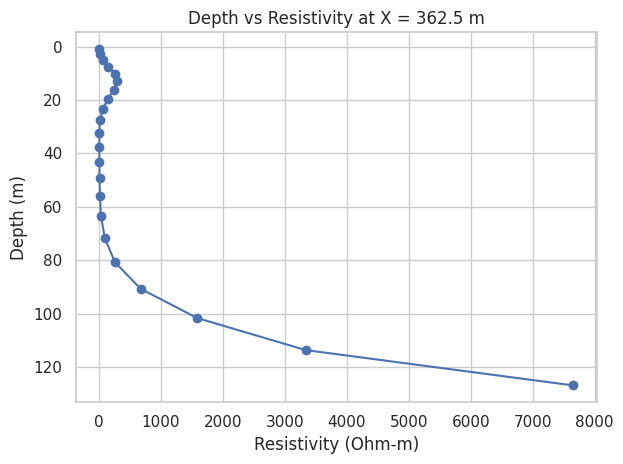

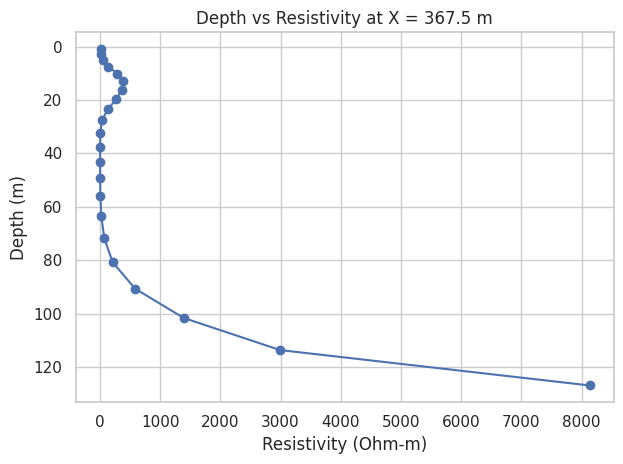

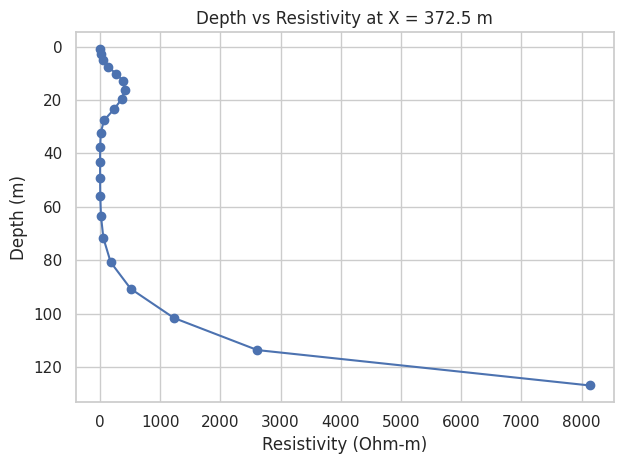

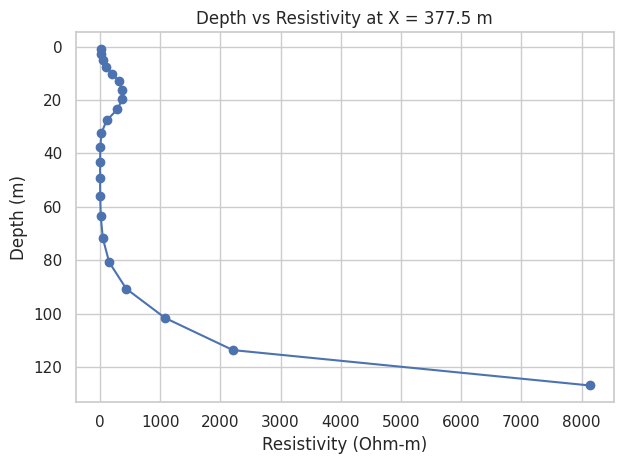

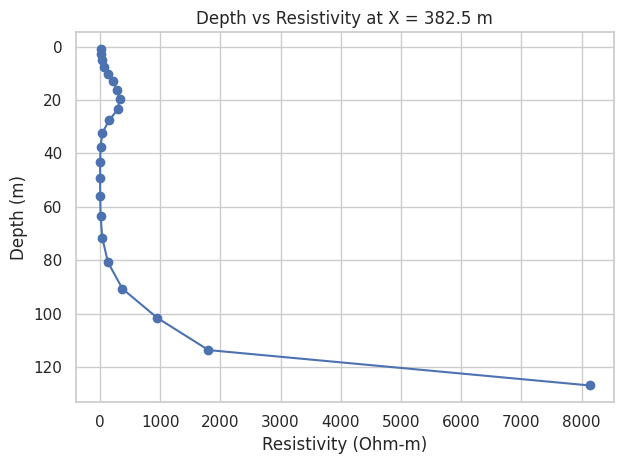

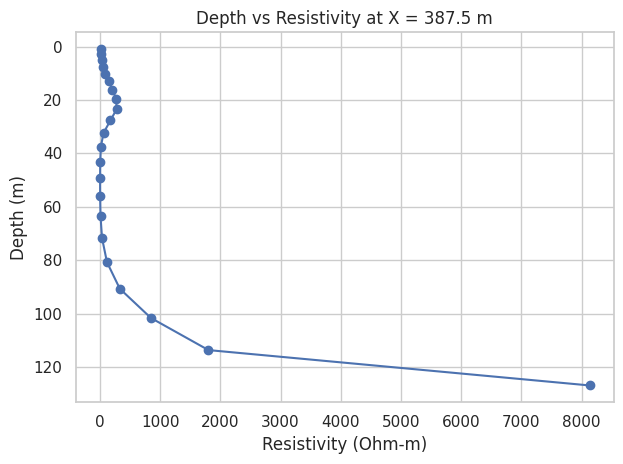

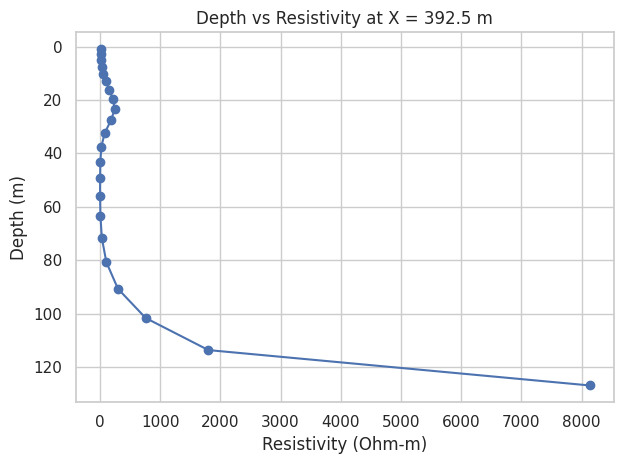

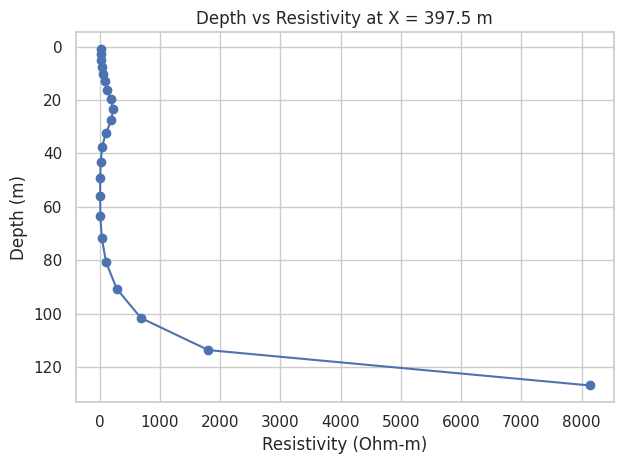

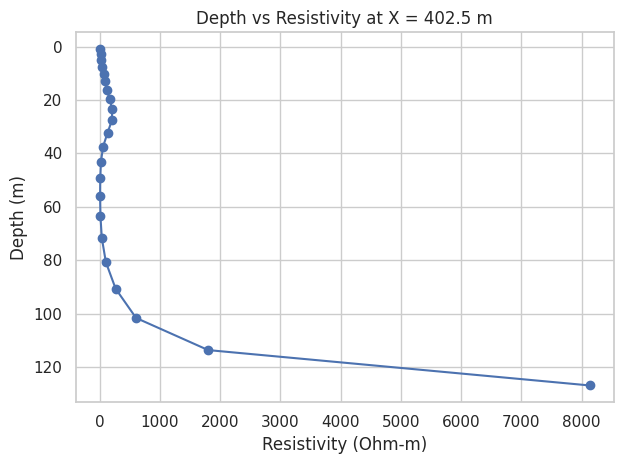

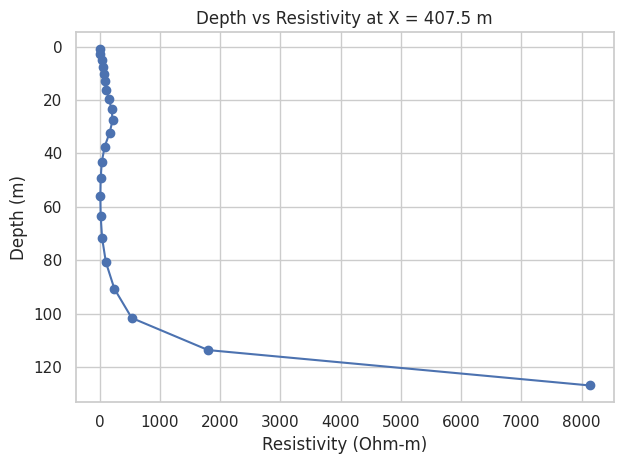

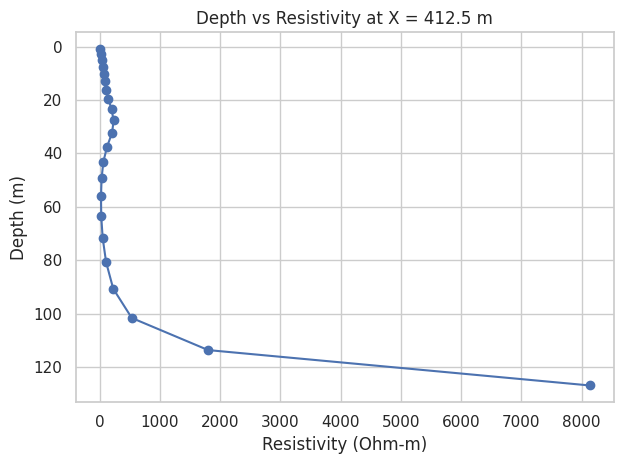

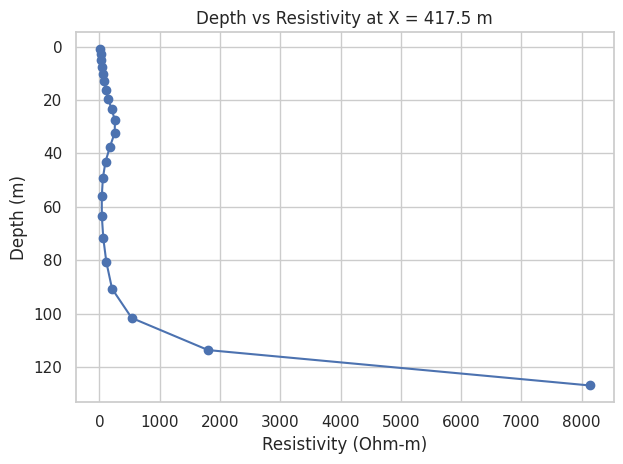

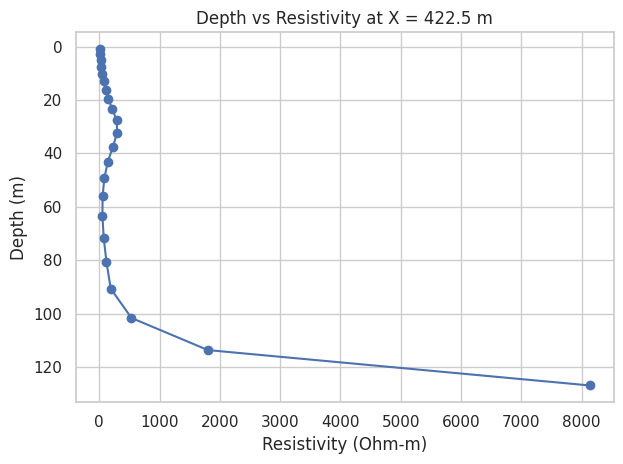

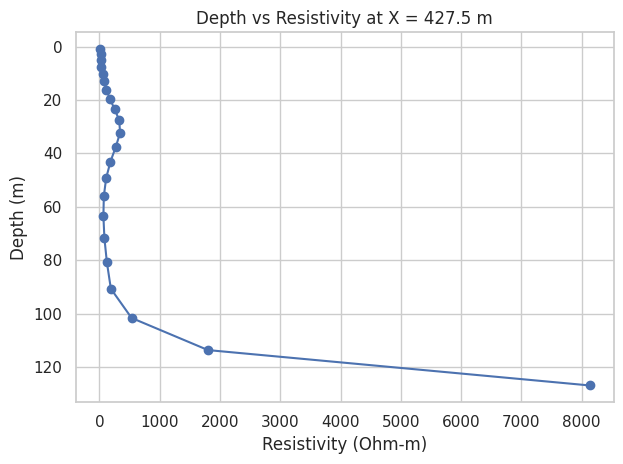

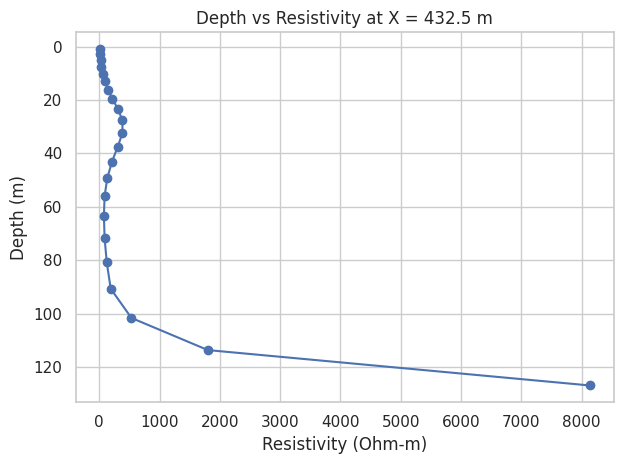

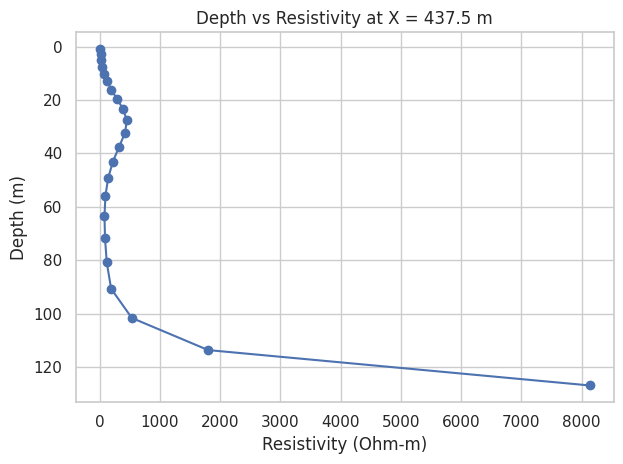

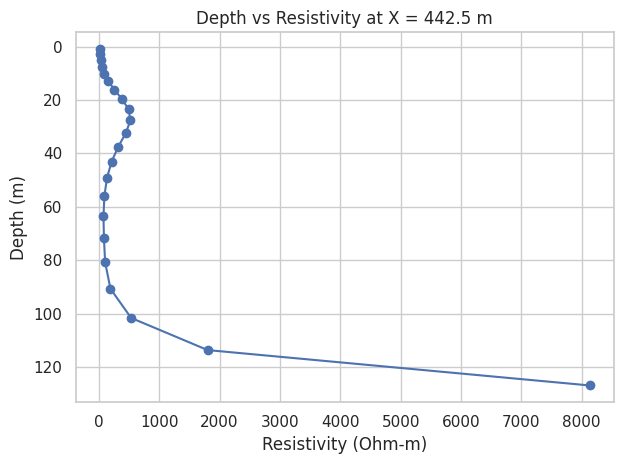

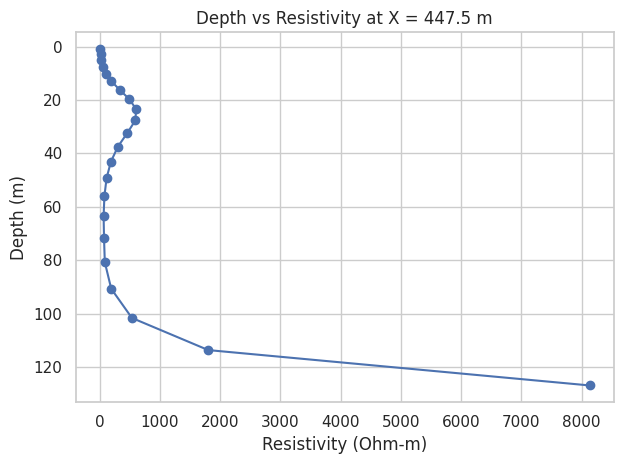

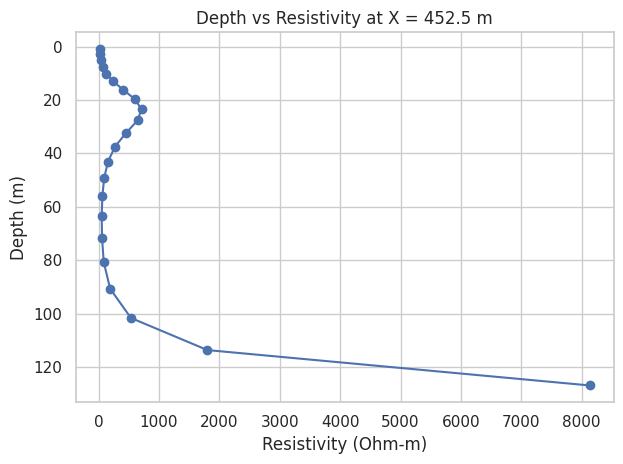

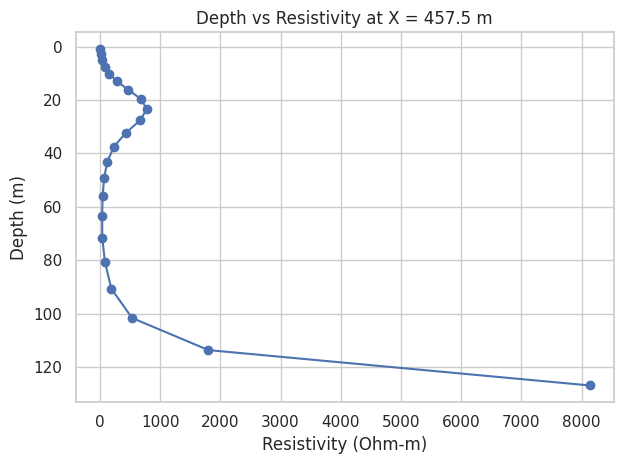

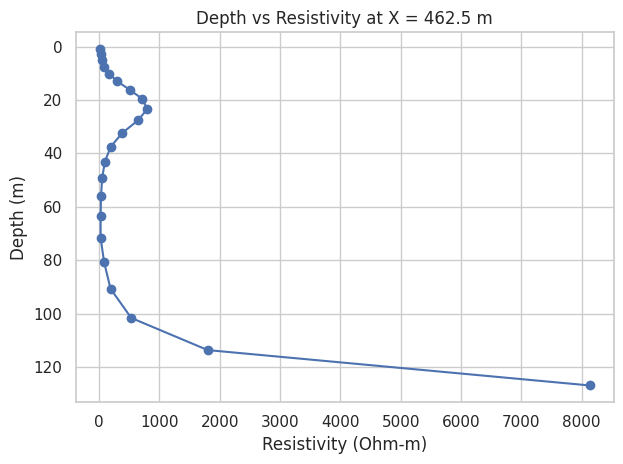

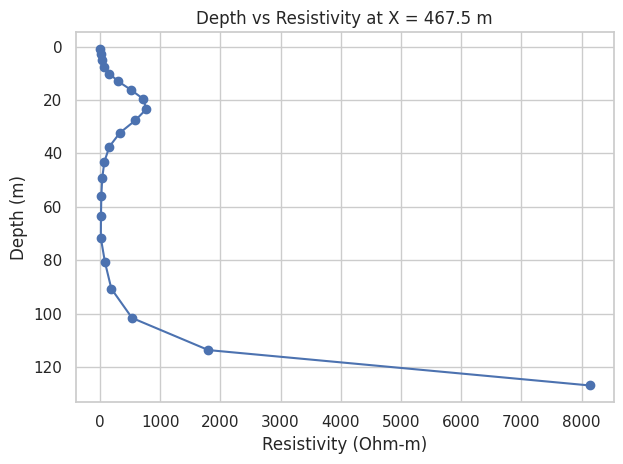

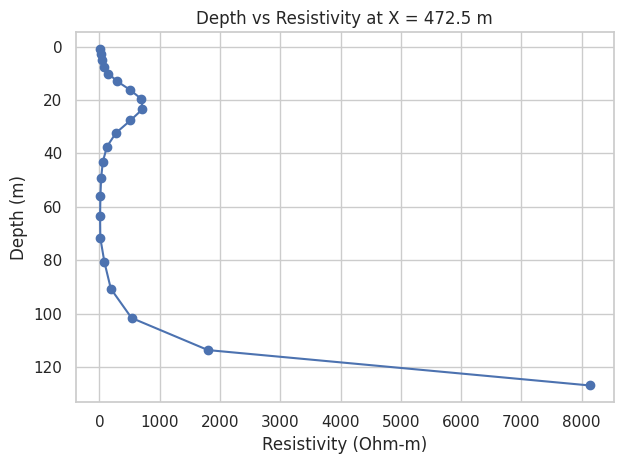

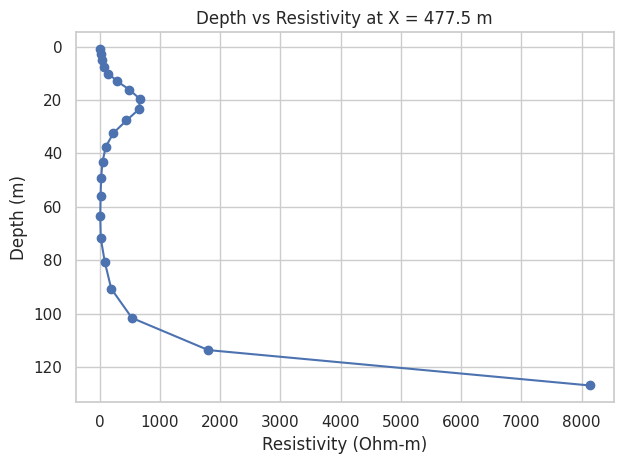

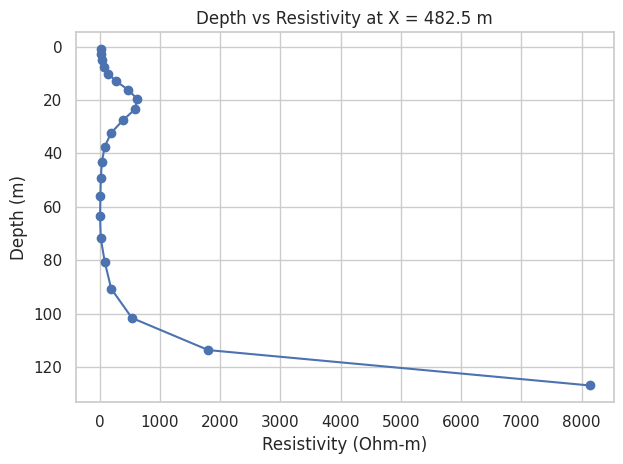

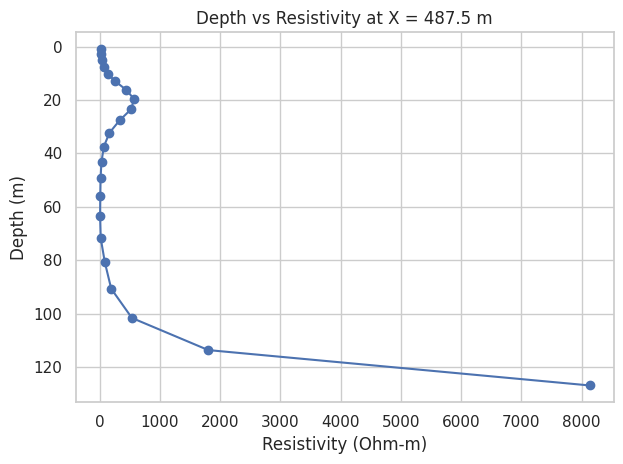

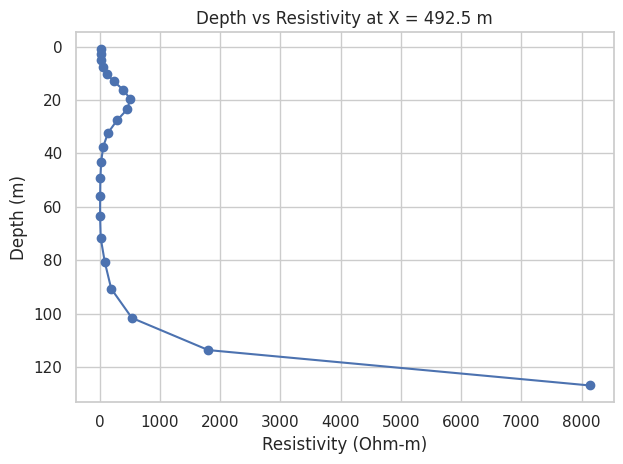

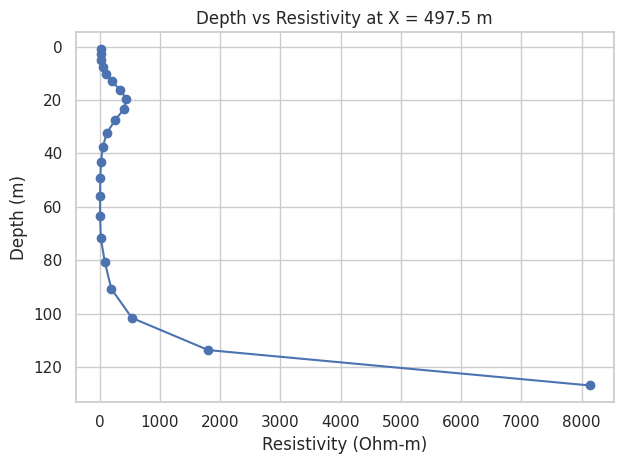

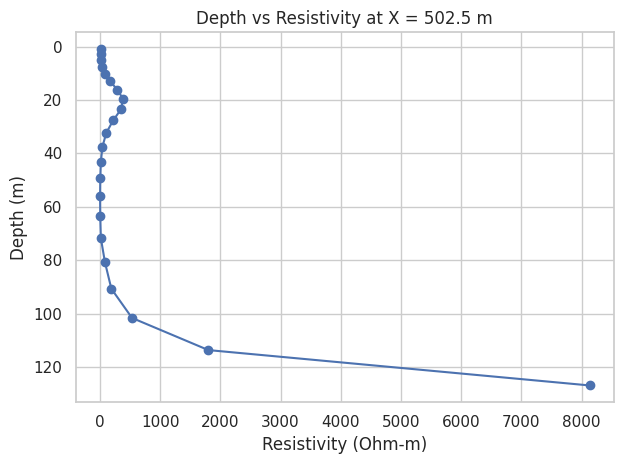

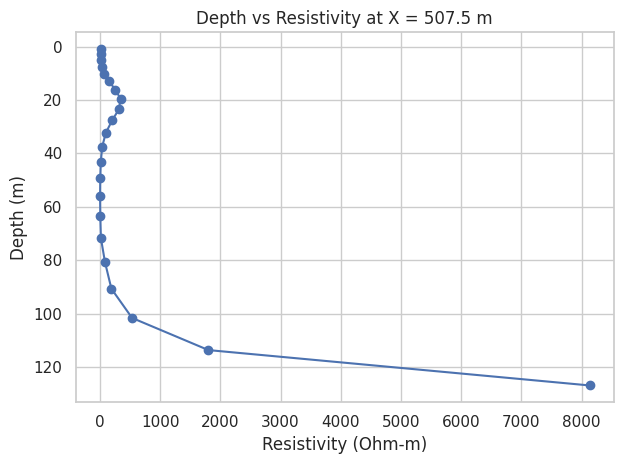

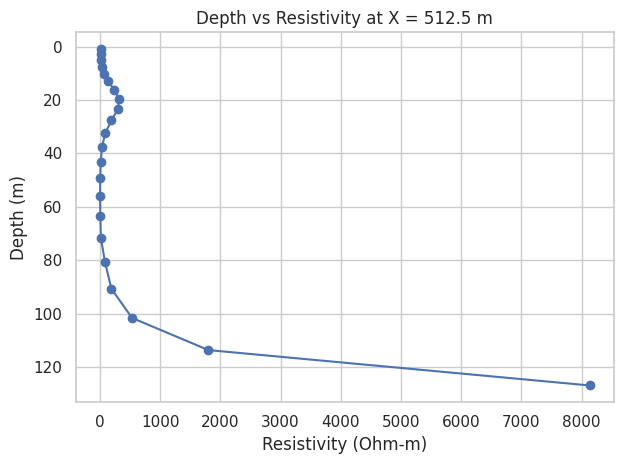

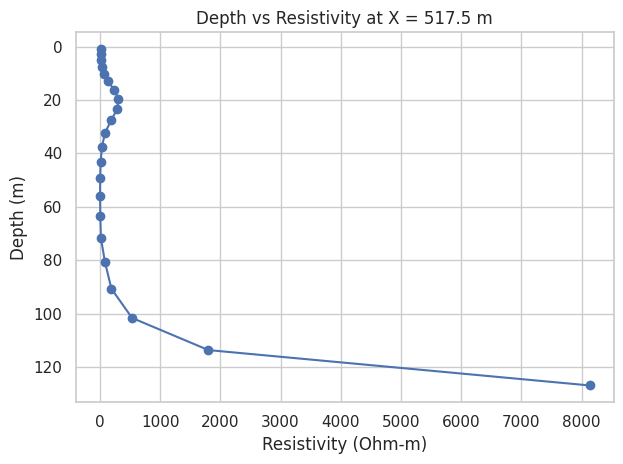

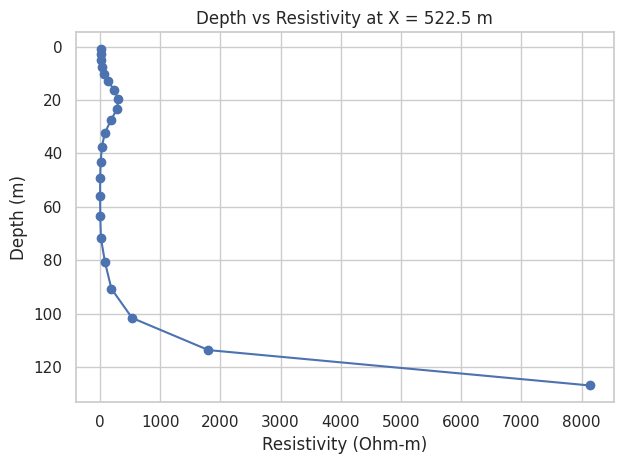

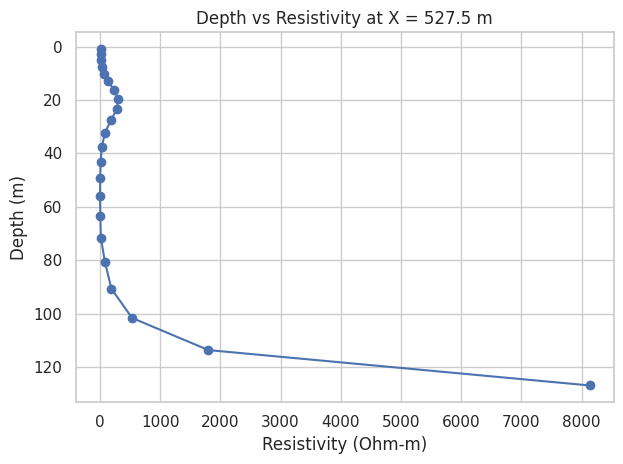

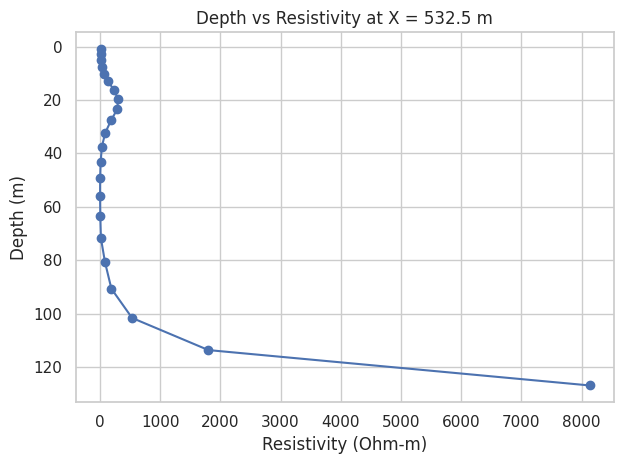

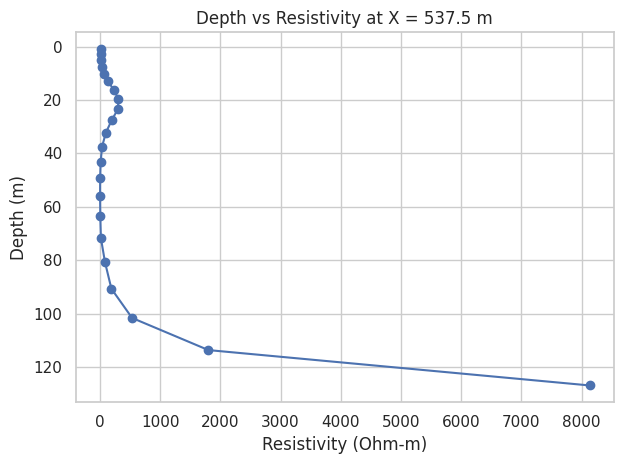

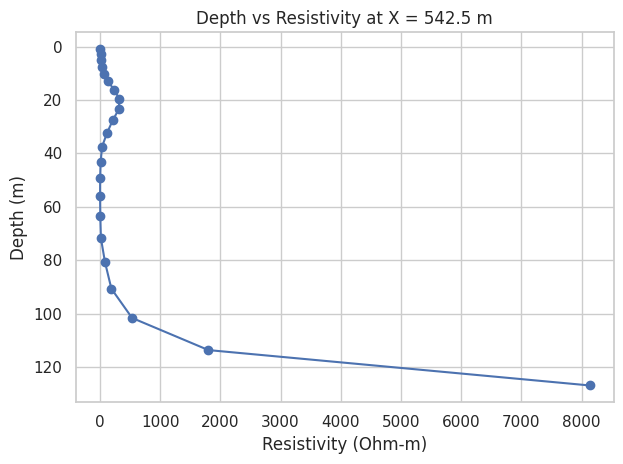

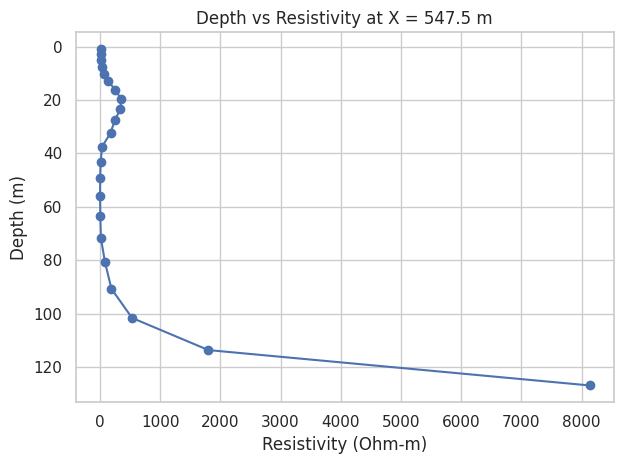

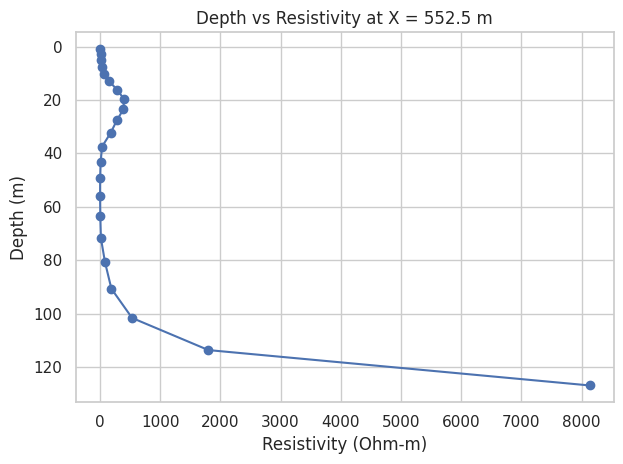

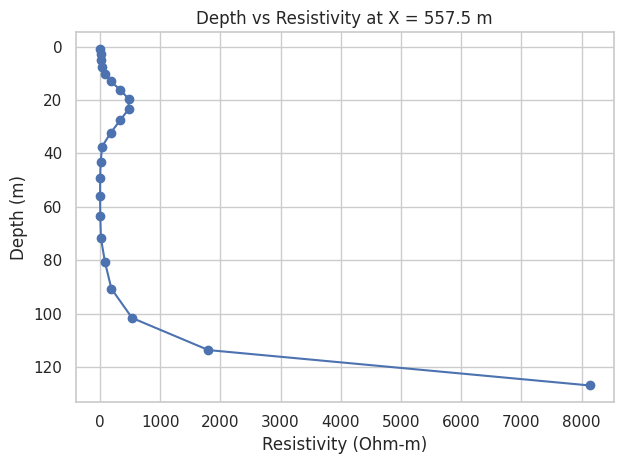

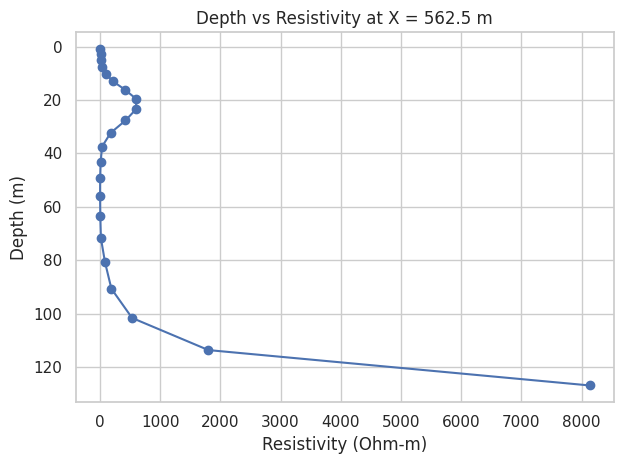

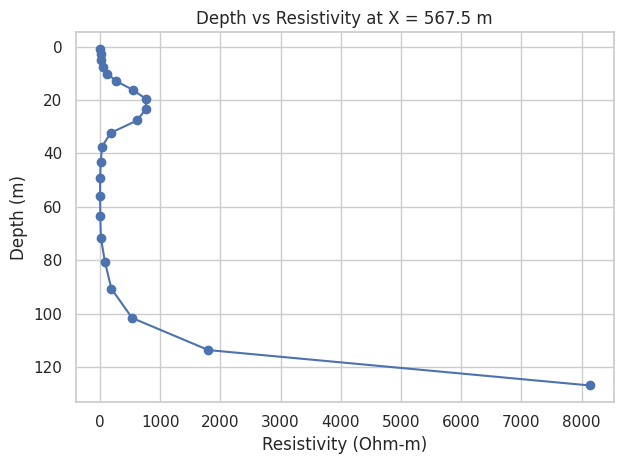

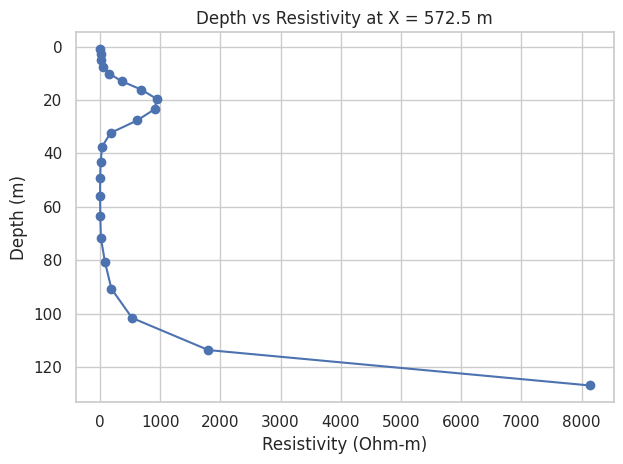

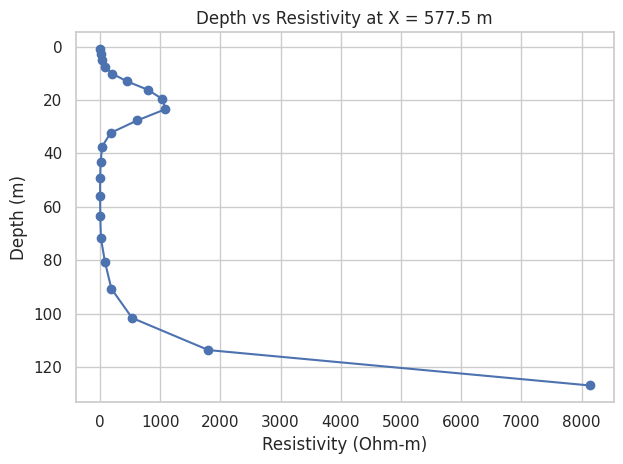

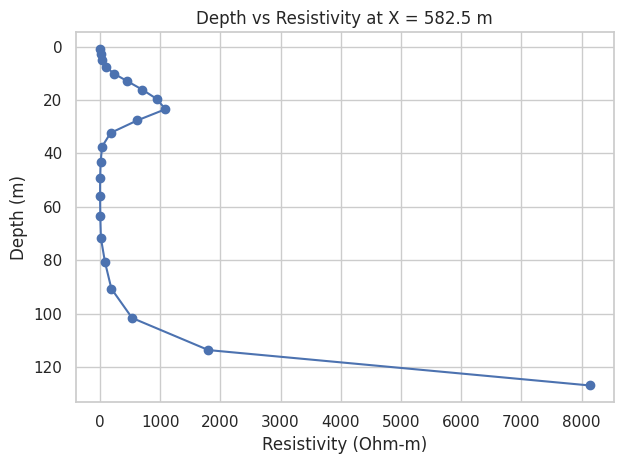

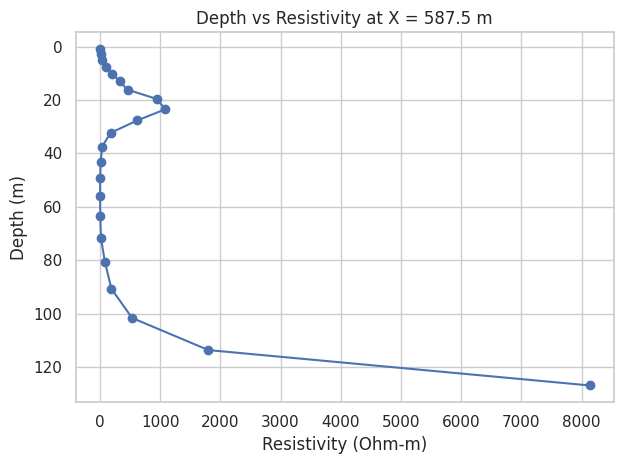

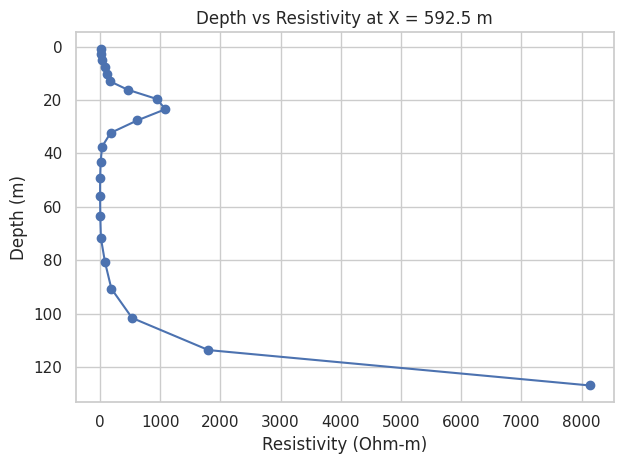

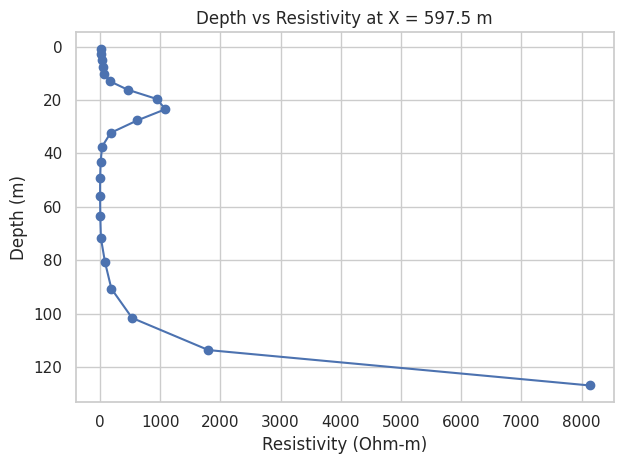

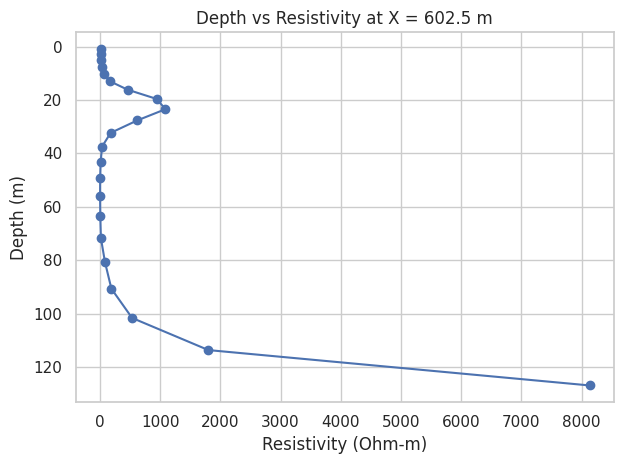

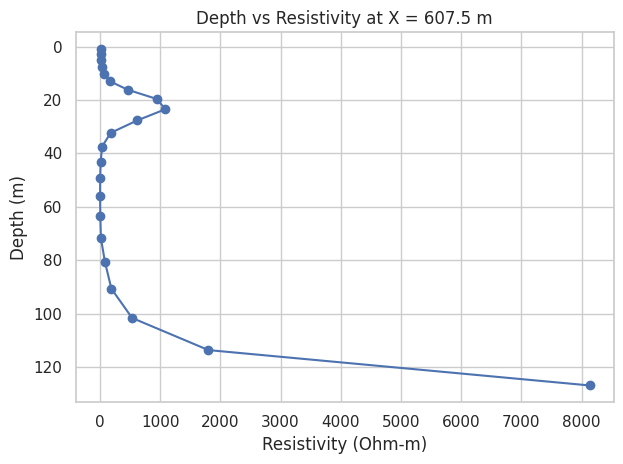

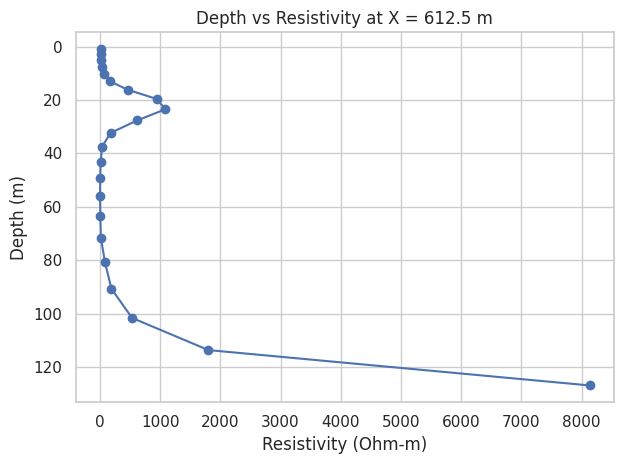

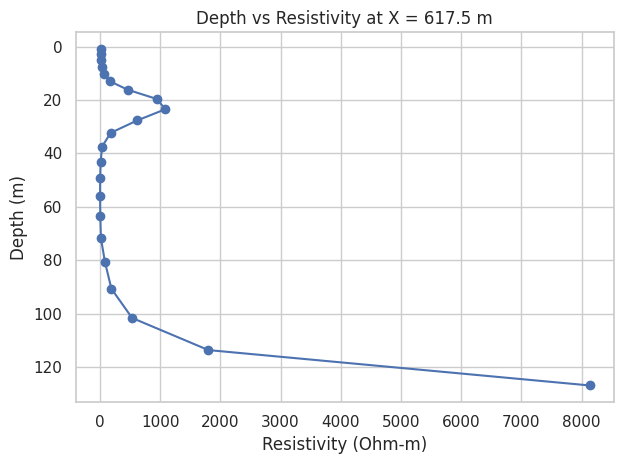

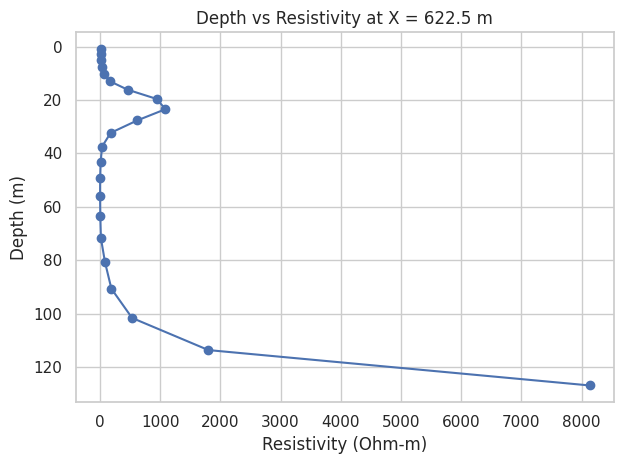

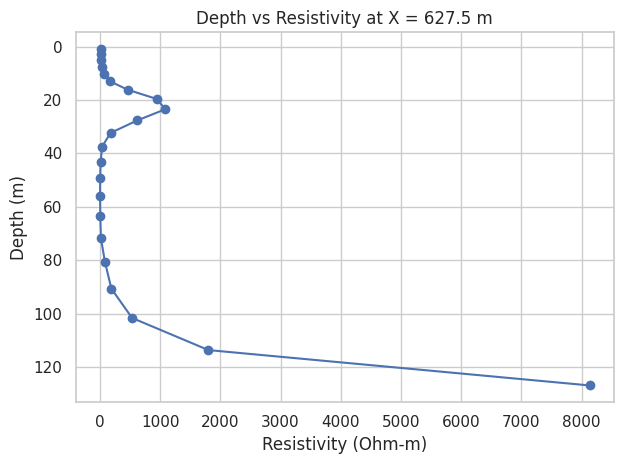

In [10]:
for x, group in grouped:
    plt.figure()
    plt.plot(group["Resistivity"], group["Depth"], marker='o')
    plt.gca().invert_yaxis()
    plt.xlabel("Resistivity (Ohm-m)")
    plt.ylabel("Depth (m)")
    plt.title(f"Depth vs Resistivity at X = {x} m")
    plt.tight_layout()
    plt.show()

Insight:

+ve → resistivity increases with depth (compaction/dry)
-ve → clay/saturation increases

In [11]:
for x, group in grouped:
    group_sorted = group.sort_values("Depth")
    filename = f"profile_X_{x}.csv"
    group_sorted.to_csv(filename, index=False)

In [12]:
pivot = df.pivot_table(values="Resistivity", index="Depth", columns="X")

print(pivot.head())

X        2.5     7.5     12.5    17.5    22.5     27.5    32.5    37.5   \
Depth                                                                     
0.938   57.480  57.480  57.480  57.480  57.480  170.155  42.918  57.463   
2.907   24.417  24.417  24.417  24.417  24.417   59.324  30.666  49.062   
5.072   11.161  11.161  11.161  11.161  11.161   25.928  25.549  53.190   
7.454   13.669  13.669  13.669  13.669  13.669   13.669  23.028  58.301   
10.075  18.916  18.916  18.916  18.916  18.916   18.916  18.916  51.500   

X         42.5     47.5   ...    582.5    587.5    592.5   597.5   602.5  \
Depth                     ...                                              
0.938    16.096   14.113  ...    8.415    7.925   15.824  10.058  18.214   
2.907    27.911   16.600  ...   14.944   17.922   22.248  16.269  13.894   
5.072    55.747   33.515  ...   36.727   42.466   41.237  28.278  18.503   
7.454    93.660   78.087  ...   96.916   97.752   77.751  48.651  29.208   
10.075  112.661  1

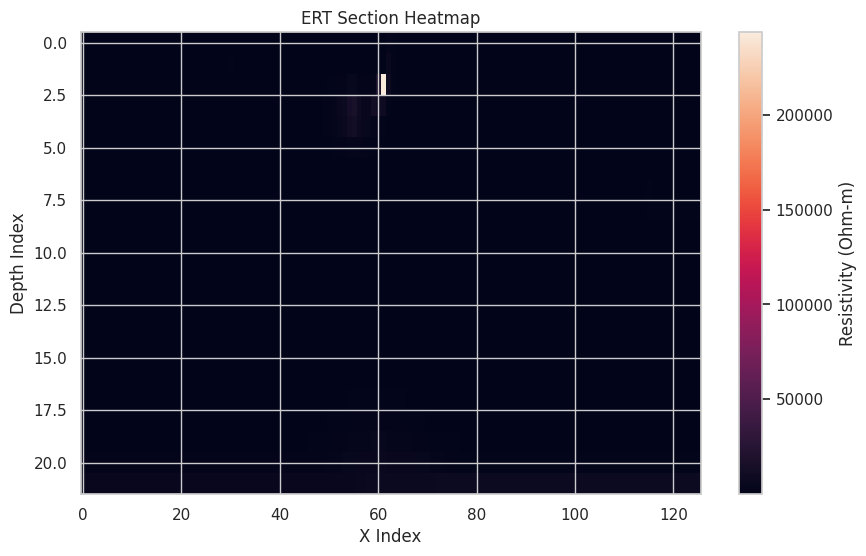

In [13]:
plt.figure(figsize=(10,6))
plt.imshow(pivot, aspect='auto', origin='upper')
plt.colorbar(label="Resistivity (Ohm-m)")
plt.xlabel("X Index")
plt.ylabel("Depth Index")
plt.title("ERT Section Heatmap")
plt.show()

In [14]:
# Create depth bins (e.g., every 1 m or 5 m)
df["Depth_bin"] = pd.cut(df["Depth"], bins=np.arange(0, df["Depth"].max()+5, 5))

depth_stats = df.groupby("Depth_bin")["Resistivity"].agg(["mean","median","std","count"])

print(depth_stats)

                       mean     median           std  count
Depth_bin                                                  
(0.0, 5.0]       113.889282    17.4645    520.571178    252
(5.0, 10.0]     1658.531044    45.4720  15484.450018    252
(10.0, 15.0]     485.023956   136.1145   1445.467261    252
(15.0, 20.0]     312.281488   271.3240    246.821337    252
(20.0, 25.0]     326.452437   227.1990    310.639761    126
(25.0, 30.0]     206.314373   149.5685    199.775646    126
(30.0, 35.0]     118.675960    98.2730    102.698015    126
(35.0, 40.0]      79.605286    58.2465     71.274995    126
(40.0, 45.0]      49.995032    15.3365     58.166043    126
(45.0, 50.0]      48.559373     7.6120     69.226969    126
(50.0, 55.0]            NaN        NaN           NaN      0
(55.0, 60.0]      58.227976     5.5805     97.269636    126
(60.0, 65.0]      79.555611     8.6370    142.588521    126
(65.0, 70.0]            NaN        NaN           NaN      0
(70.0, 75.0]     126.594270    16.4980  

/tmp/ipykernel_2639/832026438.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  depth_stats = df.groupby("Depth_bin")["Resistivity"].agg(["mean","median","std","count"])


In [15]:
high_res = df[df["Resistivity"] > df["Resistivity"].quantile(0.9)]
low_res = df[df["Resistivity"] < df["Resistivity"].quantile(0.1)]

print("High resistivity zones:", high_res.shape)
print("Low resistivity zones:", low_res.shape)

High resistivity zones: (274, 5)
Low resistivity zones: (278, 5)


3. Depth-wise Statistical Testing (Kruskal–Wallis)
✔ Create depth bins

In [16]:
df["Depth_bin"] = pd.cut(df["Depth"], bins=np.arange(0, df["Depth"].max()+5, 5))

In [17]:
groups = [group["LogRes"].values for name, group in df.groupby("Depth_bin") if len(group) > 5]

/tmp/ipykernel_2639/407033772.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["LogRes"].values for name, group in df.groupby("Depth_bin") if len(group) > 5]


In [18]:
# Import inside the same cell (safe fix)
from scipy.stats import kruskal

# Ensure groups are properly created
groups = []
for name, group in df.groupby("Depth_bin"):
    if len(group) > 5:   # avoid very small samples
        groups.append(group["LogRes"].values)

# Check before running test
if len(groups) > 1:
    stat, p_value = kruskal(*groups)

    print("Kruskal-Wallis Test:")
    print("Statistic =", stat)
    print("p-value =", p_value)
else:
    print("Not enough groups for Kruskal-Wallis test")

Kruskal-Wallis Test:
Statistic = 1563.7275021401906
p-value = 0.0


/tmp/ipykernel_2639/3960707362.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df.groupby("Depth_bin"):


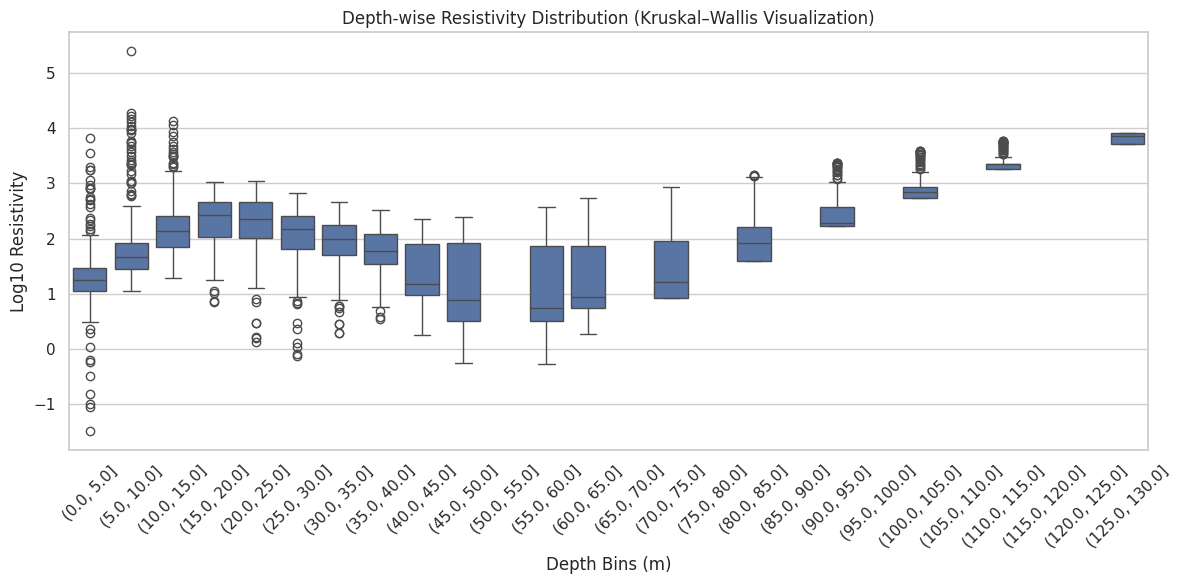

In [19]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="Depth_bin", y="LogRes")

plt.xticks(rotation=45)
plt.xlabel("Depth Bins (m)")
plt.ylabel("Log10 Resistivity")
plt.title("Depth-wise Resistivity Distribution (Kruskal–Wallis Visualization)")

plt.tight_layout()
plt.show()

This boxplot provides a statistical confirmation of the subsurface layers identified in your PCA. It tracks the Log10 Resistivity variance across depth bins, highlighting the vertical heterogeneity of the site.
## Vertical Profile Interpretation

* Surface Layer (0–5m): Low resistivity (Log10 ~1.3, approx. 20 $\Omega\cdot m$). This is a consistent, conductive top layer, likely moist soil or clay.
* The Resistive Anomaly (10–25m):
* Resistivity peaks here (Log10 ~2.4, approx. 250 $\Omega\cdot m$).
   * The large boxes and long whiskers indicate high variance, suggesting this layer is either highly fractured rock or a heterogeneous mixture of sand and gravel.
* The Transition Zone (30–50m): A steady, significant decline in median resistivity. This represents the contact zone where the resistive material gives way to more conductive underlying strata.
* Conductive Baseline (55–90m): Resistivity stabilizes at its lowest levels (Log10 ~1.0–1.4). This is the "Cluster 1" from your previous analysis—likely a saturated aquifer or a thick clay/shale unit.
* Deep Basal Trend (115m+): The median begins to climb again at the bottom of the profile, suggesting the ERT is detecting the top of a more competent, resistive basement rock.

## Statistical Note
The use of the Kruskal-Wallis visualization implies that the differences in resistivity between these depth bins are statistically significant. This confirms that your subsurface is distinctly stratified rather than a single unit with a gradual gradient.
Do you want to calculate the specific depth of the interface where the resistivity drop-off is most statistically significant?



In [20]:
from scipy.stats import kruskal, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [21]:
corr, pval = spearmanr(df["Depth"], df["LogRes"])

print("Spearman Correlation:")
print("Correlation =", corr)
print("p-value =", pval)

Spearman Correlation:
Correlation = 0.33763567547087453
p-value = 7.049661503697626e-75


In [22]:
# Import inside same cell (safe fix)
from scipy.stats import spearmanr

corr, pval = spearmanr(df["Depth"], df["LogRes"])

print("Spearman Correlation:")
print("Correlation =", corr)
print("p-value =", pval)

Spearman Correlation:
Correlation = 0.33763567547087453
p-value = 7.049661503697626e-75


In [23]:
features = df[["Depth", "LogRes"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

In [24]:
# Import required modules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare features
features = df[["Depth", "LogRes"]]

# Scale data
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled)

# Check
print(df[["Depth", "Resistivity", "Cluster"]].head())

      Depth  Resistivity  Cluster
0     0.938       57.480        0
126   2.907       24.417        0
252   5.072       11.161        0
378   7.454       13.669        0
504  10.075       18.916        0


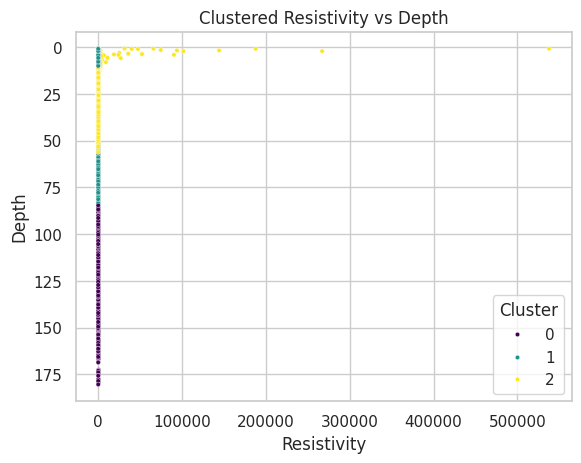

In [ ]:
plt.figure()
sns.scatterplot(data=df, x="Resistivity", y="Depth", hue="Cluster", palette="viridis", s=10)
plt.gca().invert_yaxis()
plt.title("Clustered Resistivity vs Depth")
plt.show()

This plot categorizes the subsurface into three distinct electro-facies based on their resistivity response relative to depth:
## Cluster Analysis

* Cluster 2 (Yellow) – High Resistivity Zone (Depth ~10–45):
* This is the most significant feature. It represents a highly resistive layer ($100$ to $>1500\ \Omega\cdot m$).
   * Geological Interpretation: Likely dry sand, gravel, or a competent bedrock layer (e.g., limestone or granite) located between 10 and 45 depth units. The wide scatter suggests high heterogeneity or varying degrees of weathering.
* Cluster 0 (Purple) – Shallow Conductive Zone (Depth ~0–30):
* Characterized by very low resistivity ($<100\ \Omega\cdot m$) at the surface.
   * Geological Interpretation: Represents topsoil, organic matter, or moisture-rich clay layers near the surface.
* Cluster 1 (Teal) – Deep Conductive Zone (Depth ~45–120):
* Similar low resistivity values to Cluster 0 but located at greater depths.
   * Geological Interpretation: Likely indicates a saturated zone (aquifer), a clay-rich basement, or weathered shale. The separation from Cluster 0 suggests a different geological unit despite similar resistivity values.

## Key Observations

* Horizontal Banding: The data points align on specific horizontal lines, which are the discrete inversion grid levels from your ERT software.
* Resistivity Contrast: There is a massive contrast between Cluster 2 and the others. This suggests a sharp lithological contact (e.g., soil sitting directly on top of a rock unit, which then transitions into a saturated zone).

Would you like to cross-plot these clusters against a different parameter, such as chargeability (IP), to see if Cluster 2 is mineralized or purely resistive?



In [25]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

df["PC1"] = pca_result[:,0]
df["PC2"] = pca_result[:,1]

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.71194971 0.28805029]


In [26]:
# Import PCA
from sklearn.decomposition import PCA

# Run PCA on scaled data (IMPORTANT: use same 'scaled')
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

# Add to dataframe
df["PC1"] = pca_result[:, 0]
df["PC2"] = pca_result[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.71194971 0.28805029]


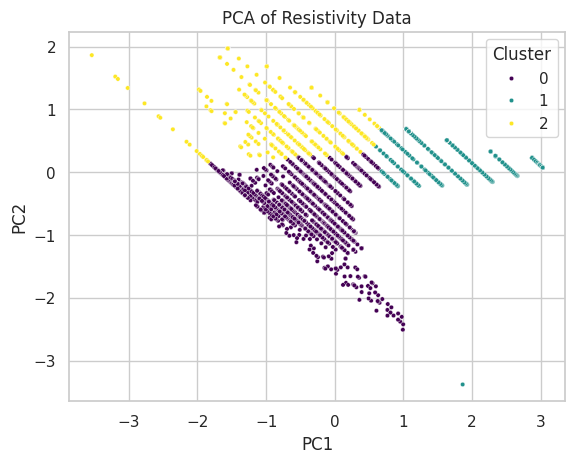

In [27]:
plt.figure()
sns.scatterplot(x=df["PC1"], y=df["PC2"], hue=df["Cluster"], palette="viridis", s=10)
plt.title("PCA of Resistivity Data")
plt.show()

The provided PCA (Principal Component Analysis) plot reduces the complexity of Electrical Resistivity Tomography (ERT) data to highlight distinct subsurface features.
#Interpretation Summary
Principal Components (PC1 & PC2): These axes represent the "summarized" variation in resistivity values.
PC1 (X-axis): Captures the most significant variance, likely related to broad lithological changes (e.g., the transition from soil to bedrock) or large-scale moisture gradients.
PC2 (Y-axis): Captures secondary variance, which often relates to smaller-scale properties like salinity, porosity, or mineralogical variations within a layer.


#Clustering (Geophysical Facies):
The data is grouped into three distinct clusters, suggesting the subsurface contains three primary geophysical zones:
Cluster 2 (Yellow): Distinctly separated on the negative PC1 side. This likely represents a major geological unit or a specific depth range (e.g., a topsoil layer or unsaturated zone).
Clusters 0 & 1 (Purple & Teal): These group together on the positive PC1 side but are separated by PC2. This suggests they share a similar base material but differ in secondary characteristics, such as saturation levels or clay content.


#Linear Patterns:
The diagonal "stripping" visible in the clusters is a common artifact in geophysical data. It typically reflects the discrete levels of the ERT inversion grid or specific electrode spacings used during data collection.


#Subsurface Implications
This analysis suggests that the site is not geophysically uniform. The clear separation between the yellow cluster and the others indicates a sharp boundary in the subsurface, such as a lithological contact or a water table interface.
Would you like to correlate these clusters with a specific geological profile or borehole log?

#Shanon Entropy

In [28]:
bins = [0, 10, 50, 100, np.inf]
labels = ["Clay", "Silty Sand", "Sand", "Aquifer"]

df["Class"] = pd.cut(df["Resistivity"], bins=bins, labels=labels)

In [29]:
class_counts = df["Class"].value_counts(normalize=True)

entropy = -np.sum(class_counts * np.log(class_counts))

print("Shannon Entropy =", entropy)

Shannon Entropy = 1.2329519230993848


Lateral Zonation Testing

In [30]:
# Divide into zones
df["Zone"] = pd.cut(df["X"], bins=3, labels=["A", "B", "C"])

zone_groups = [group["LogRes"].values for name, group in df.groupby("Zone")]

stat, p_value = kruskal(*zone_groups)

print("Lateral Variation Test:")
print("Statistic =", stat)
print("p-value =", p_value)

Lateral Variation Test:
Statistic = 88.09942040669364
p-value = 7.40378722559369e-20


/tmp/ipykernel_2639/4275807299.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_groups = [group["LogRes"].values for name, group in df.groupby("Zone")]


Trend Analysis (Depth Profile) Mean Resistivity Profile along Depth

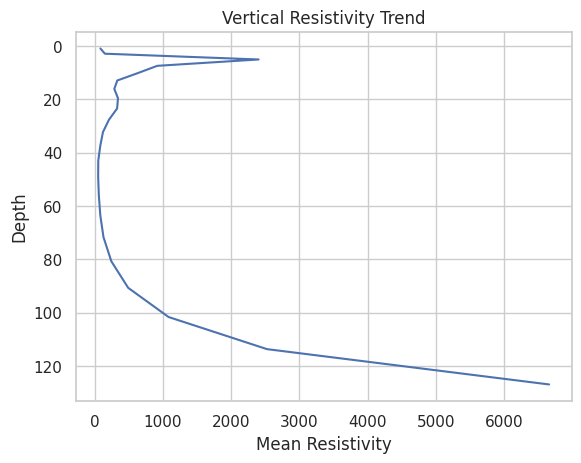

In [31]:
# Mean resistivity vs depth
depth_mean = df.groupby("Depth")["Resistivity"].mean()

plt.figure()
plt.plot(depth_mean.values, depth_mean.index)
plt.gca().invert_yaxis()
plt.xlabel("Mean Resistivity")
plt.ylabel("Depth")
plt.title("Vertical Resistivity Trend")
plt.show()

Insight:

+ve → resistivity increases with depth (compaction/dry)
-ve → clay/saturation increases

# K means Cluster Geoelectrical Facies

In [32]:
cluster_stats = df.groupby("Cluster")["Resistivity"].agg(["mean","min","max","count"])

print(cluster_stats)

                mean      min         max  count
Cluster                                         
0         334.307054    5.528   18283.758   1537
1        2763.258413  102.992  243450.047    595
2          20.779416    0.033     121.819    640


| Resistivity (Ω·m) | Lithology        |
| ----------------- | ---------------- |
| <10               | Clay / saturated |
| 10–50             | Silty sand       |
| 50–100            | Sand             |
| >100              | Dense/dry        |


#Applying Labelling

In [33]:
def assign_lithology(res):
    if res < 10:
        return "Clay"
    elif res < 50:
        return "Silty Sand"
    elif res < 100:
        return "Sand"
    else:
        return "Dense Layer"

df["Lithology"] = df["Resistivity"].apply(assign_lithology)

#Compare Cluster vs Lithology

In [34]:
comparison = pd.crosstab(df["Cluster"], df["Lithology"])

print(comparison)

Lithology  Clay  Dense Layer  Sand  Silty Sand
Cluster                                       
0            31          772   332         402
1             0          595     0           0
2           328            3    78         231


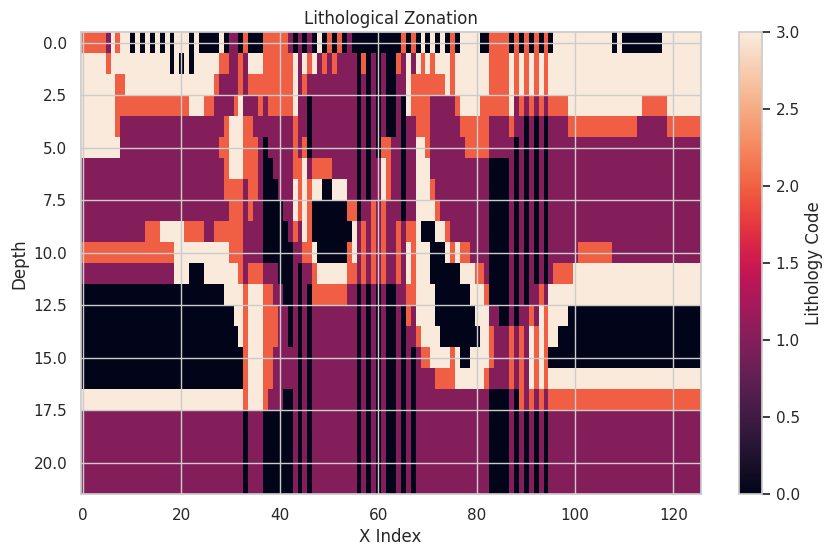

In [35]:
pivot_lith = df.pivot_table(values="Lithology", index="Depth", columns="X", aggfunc=lambda x: x.mode()[0])

plt.figure(figsize=(10,6))
plt.imshow(pivot_lith.apply(lambda col: col.astype('category').cat.codes), aspect='auto', origin='upper')
plt.colorbar(label="Lithology Code")
plt.title("Lithological Zonation")
plt.xlabel("X Index")
plt.ylabel("Depth")
plt.show()

#DUNN’S POST-HOC TEST (After Kruskal–Wallis)

Since your Kruskal test is significant, Dunn’s test tells:

🔥 Which specific depth layers are different from each other

In [36]:
!pip install scikit-posthocs seaborn openpyxl

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
import scikit_posthocs as sp

sns.set(style="whitegrid")

In [38]:
file_path = "/content/santosh01.xlsx"   # 🔁 change this

df = pd.read_excel(file_path)

# Rename columns (based on your format)
df.columns = ["X", "Depth", "Resistivity"]

# Convert to numeric (important)
df["Depth"] = pd.to_numeric(df["Depth"], errors="coerce")
df["Resistivity"] = pd.to_numeric(df["Resistivity"], errors="coerce")

# Drop missing values
df = df.dropna()

# Convert depth to positive
df["Depth"] = df["Depth"].abs()

# Remove invalid resistivity
df = df[df["Resistivity"] > 0]

# Log transform
df["LogRes"] = np.log10(df["Resistivity"])

print("Data shape:", df.shape)
print("Depth range:", df["Depth"].min(), "to", df["Depth"].max())

Data shape: (2772, 4)
Depth range: 0.938 to 126.943


In [39]:
bin_size = 5

df["Depth_bin"] = pd.cut(
    df["Depth"],
    bins=np.arange(0, df["Depth"].max() + bin_size + 1e-6, bin_size),
    include_lowest=True
)

In [40]:
df = df.dropna(subset=["Depth_bin"])

In [41]:
df["Depth_bin"] = df["Depth_bin"].astype(str)

In [42]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    df,
    val_col="LogRes",
    group_col="Depth_bin",
    p_adjust="bonferroni"
)

print(dunn)

                (-0.001, 5.0]  (10.0, 15.0]  (100.0, 105.0]  (110.0, 115.0]  \
(-0.001, 5.0]    1.000000e+00  3.321476e-32    1.236018e-75    1.254480e-95   
(10.0, 15.0]     3.321476e-32  1.000000e+00    5.605452e-16    5.574513e-26   
(100.0, 105.0]   1.236018e-75  5.605452e-16    1.000000e+00    1.000000e+00   
(110.0, 115.0]   1.254480e-95  5.574513e-26    1.000000e+00    1.000000e+00   
(125.0, 130.0]  5.998664e-113  1.895022e-35    5.271701e-02    1.000000e+00   
(15.0, 20.0]     1.775414e-47  1.000000e+00    7.347997e-09    9.145576e-17   
(20.0, 25.0]     1.008016e-27  1.000000e+00    3.662172e-08    1.146332e-14   
(25.0, 30.0]     3.713785e-17  1.000000e+00    7.779064e-15    4.211661e-23   
(30.0, 35.0]     2.532859e-09  1.756286e-01    7.063205e-23    7.842539e-33   
(35.0, 40.0]     1.528292e-03  3.949797e-06    7.789029e-33    1.589379e-44   
(40.0, 45.0]     1.000000e+00  1.379869e-17    2.293488e-51    1.042013e-65   
(45.0, 50.0]     1.000000e+00  5.032221e-24    2.123

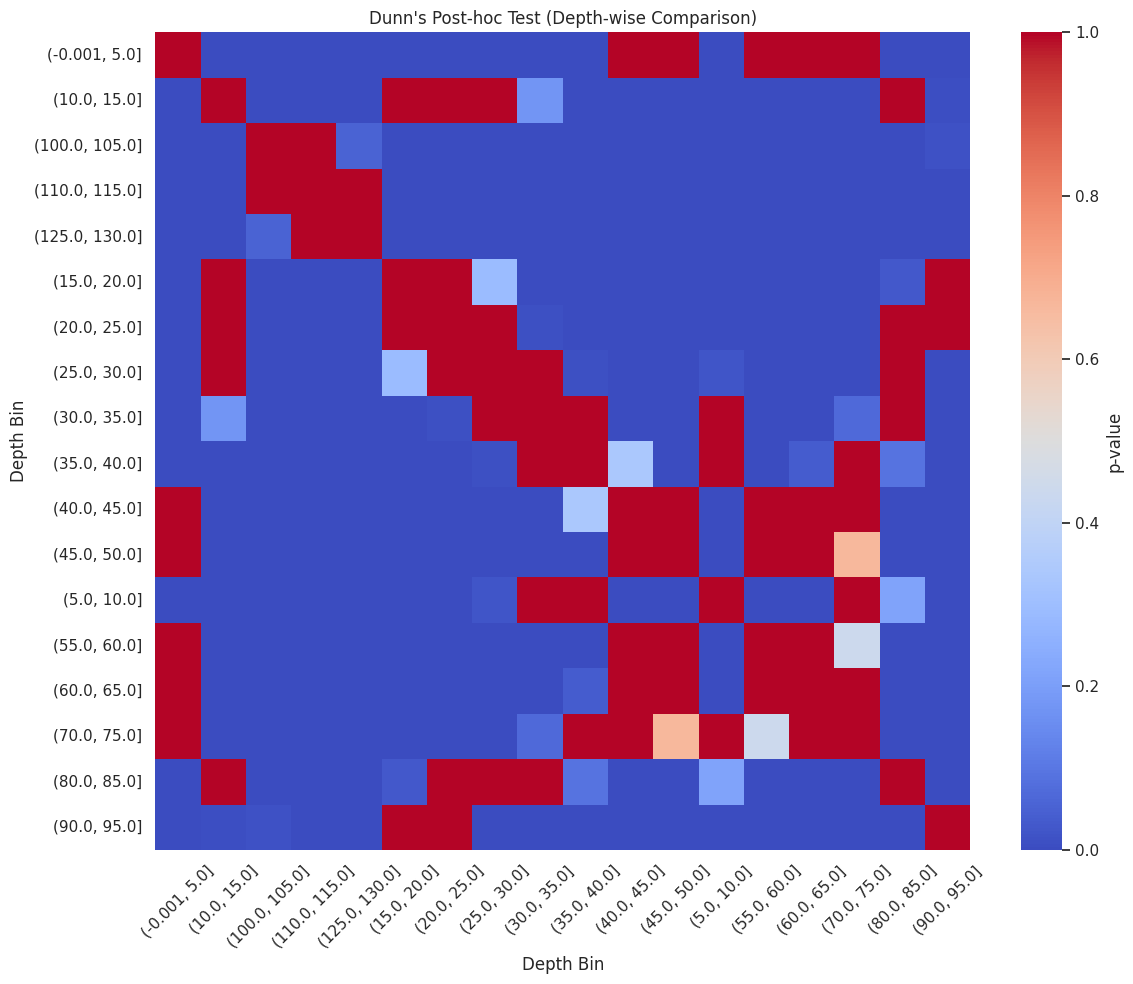

In [43]:
plt.figure(figsize=(12,10))

sns.heatmap(
    dunn,
    annot=False,          # change to True if matrix is small
    cmap="coolwarm",
    cbar_kws={'label': 'p-value'}
)

plt.title("Dunn's Post-hoc Test (Depth-wise Comparison)")
plt.xlabel("Depth Bin")
plt.ylabel("Depth Bin")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

This Dunn’s Post-hoc Test heatmap provides a statistical "fingerprint" of your subsurface boundaries. It identifies which depth intervals are geophysically identical (Red) and which are significantly different (Blue).
## Statistical Interpretation

* Red Zones ($p > 0.05$): Indicate Geophysical Homogeneity. These depth bins share the same resistivity characteristics and can be grouped into the same geological unit.
* Blue Zones ($p < 0.05$): Indicate Statistically Significant Boundaries. A transition from red to blue across the axes marks a lithological or hydrogeological contact.

------------------------------
## Key Subsurface Findings

| Statistical Feature | Depth Bins | Geological Correlation |
|---|---|---|
| The Resistive "Island" | (10.0, 30.0] | The large blue blocks surrounding these rows confirm this layer is statistically unique from everything else. It is a distinct, high-resistivity body (likely the dry sand/rock lens identified in your PCA). |
| Deep Homogeneous Unit | (55.0, 85.0] | The solid red cluster in the bottom-right indicates these depths are statistically indistinguishable. This is a massive, uniform unit (likely a saturated aquifer or thick clay). |
| Surface-to-Deep Similarity | (0, 5] vs. (70, 85] | Interestingly, the surface (0-5m) shows red (similarity) with the deep zone (70-85m). This suggests the topsoil and the deep saturated layer have nearly identical resistivity signatures ($20-30\ \Omega\cdot m$). |
| The 95m Boundary | (95.0, 100.0] | Note the shift to blue when comparing 95m+ to the 55-85m block. This statistically confirms the start of the basement rock transition. |

## Summary of Stratigraphy
The heatmap identifies four statistically distinct zones:

   1. Zone A (0–10m): Conductive surface.
   2. Zone B (10–35m): High-resistivity anomaly (the most unique feature).
   3. Zone C (40–90m): Low-resistivity, uniform conductive layer.
   4. Zone D (95m+): Transition to a new, more resistive basal unit.




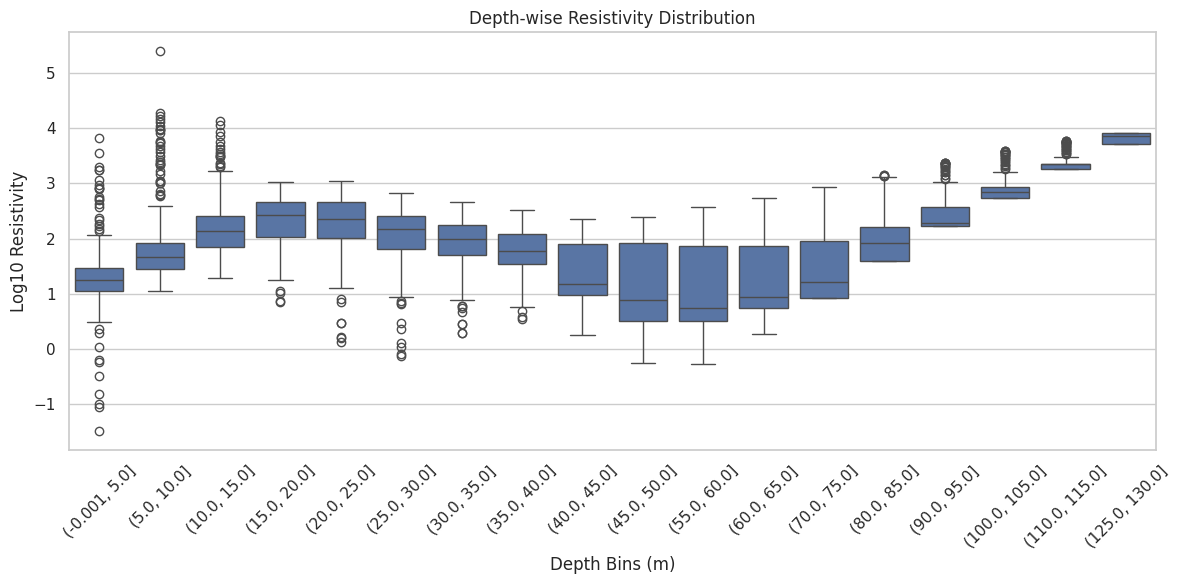

In [44]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="Depth_bin", y="LogRes")

plt.xticks(rotation=45)
plt.xlabel("Depth Bins (m)")
plt.ylabel("Log10 Resistivity")
plt.title("Depth-wise Resistivity Distribution")

plt.tight_layout()
plt.show()

# Interpretation of Kruskal and Dunns Stats
“The Kruskal–Wallis test indicated significant variation in resistivity across depth intervals (p < 0.001). Dunn’s post-hoc analysis further revealed that shallow and deeper layers are statistically distinct, confirming strong vertical heterogeneity within the subsurface.”

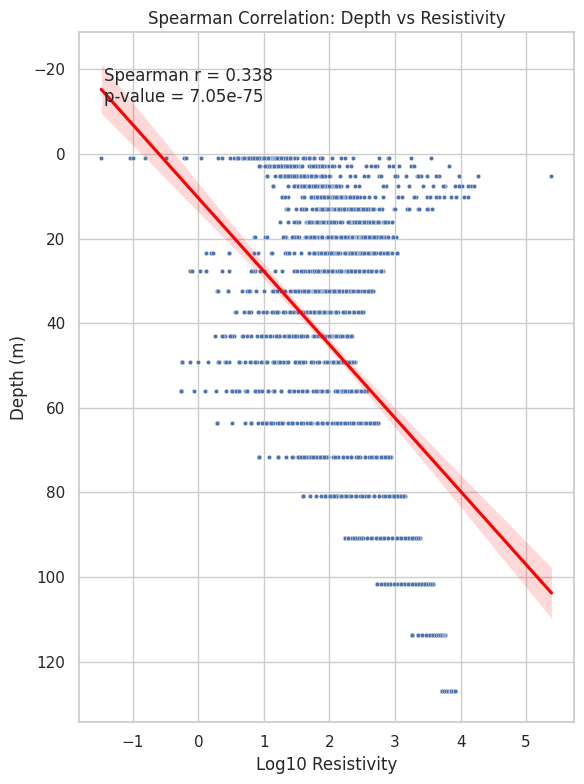

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Compute correlation
corr, pval = spearmanr(df["Depth"], df["LogRes"])

# Plot
plt.figure(figsize=(6,8))

sns.scatterplot(x=df["LogRes"], y=df["Depth"], s=10)

# Add trend line (optional but useful)
sns.regplot(x=df["LogRes"], y=df["Depth"],
            scatter=False, color="red")

# Invert depth axis (important for geophysics)
plt.gca().invert_yaxis()

plt.xlabel("Log10 Resistivity")
plt.ylabel("Depth (m)")
plt.title("Spearman Correlation: Depth vs Resistivity")

# Annotate correlation
plt.text(
    0.05, 0.95,
    f"Spearman r = {corr:.3f}\np-value = {pval:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.tight_layout()
plt.show()

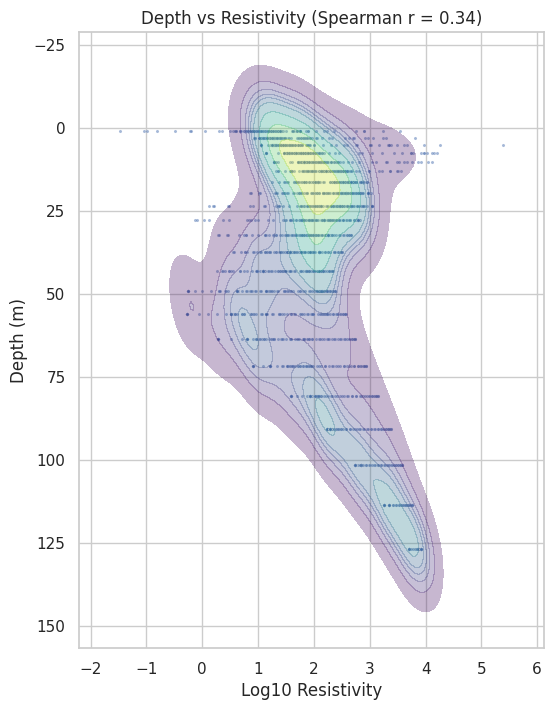

In [46]:
plt.figure(figsize=(6,8))

sns.scatterplot(x=df["LogRes"], y=df["Depth"], s=5, alpha=0.5)

sns.kdeplot(
    x=df["LogRes"], y=df["Depth"],
    fill=True, cmap="viridis", alpha=0.3
)

plt.gca().invert_yaxis()

plt.xlabel("Log10 Resistivity")
plt.ylabel("Depth (m)")
plt.title(f"Depth vs Resistivity (Spearman r = {corr:.2f})")

plt.show()

This Density-Scatter Plot confirms the lack of a linear relationship between depth and resistivity, providing a visual "map" of your subsurface layers.
## Key Statistical & Physical Interpretations

* Spearman $r = 0.06$ (Near Zero): This is the most critical statistical finding. It confirms there is no monotonic trend (resistivity does not simply increase or decrease with depth). Instead, the subsurface is characterized by discrete, contrasting layers.
* The "Dual-Peak" Surface (0–30m):
* The KDE (contour) map shows two distinct "islands" of high data density at shallow depths.
   * Peak 1 (Log10 ~1.4): Represents the conductive topsoil/clay.
   * Peak 2 (Log10 ~2.4): Represents the resistive lens (sand/rock) identified in your previous PCA. The fact that these exist at the same depth range suggests lateral heterogeneity—the resistive unit isn't a flat sheet across the whole site.
* The Deep "Funnel" (40m – 120m):
* As you go deeper, the spread of resistivity narrows significantly.
   * The data "funnels" into a consistent range ($\log_{10} 1.2$ to $1.8$). This indicates a transition from complex, mixed near-surface materials into a massive, uniform geological unit (likely a saturated zone or thick clay-rich basement).
* Vertical Banding: The horizontal rows of dots are "artifacts" of the ERT inversion grid levels. They show exactly which depths your software sampled.

## Synthesis with Previous Results
This plot explains why your PCA and Dunn’s test were so successful:

   1. PCA separated the two "islands" at the top.
   2. Dunn’s Test flagged the 10–30m range as unique because that is where the density shifts most dramatically to the right (the resistive side).
   3. The "Tail" at the bottom (120m+) shows the start of an upward trend in resistivity, confirming the "basement rock" transition you suspected.

Would you like to generate a final interpreted cross-section or a lithological table that summarizes these findings for a report?



#Lateral Inhomogeneity Testing

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal, mannwhitneyu, f_oneway

sns.set(style="whitegrid")

In [49]:
file_path = "/content/santosh01.xlsx"

df = pd.read_excel(file_path)
df.columns = ["X", "Depth", "Resistivity"]

# Cleaning
df["Depth"] = pd.to_numeric(df["Depth"], errors="coerce").abs()
df["Resistivity"] = pd.to_numeric(df["Resistivity"], errors="coerce")

df = df.dropna()
df = df[df["Resistivity"] > 0]

# Log transform
df["LogRes"] = np.log10(df["Resistivity"])

print("Data shape:", df.shape)

Data shape: (2772, 4)


In [50]:
segment_size = 50

df["Segment"] = (df["X"] // segment_size) * segment_size

print(df["Segment"].unique())

[  0.  50. 100. 150. 200. 250. 300. 350. 400. 450. 500. 550. 600.]


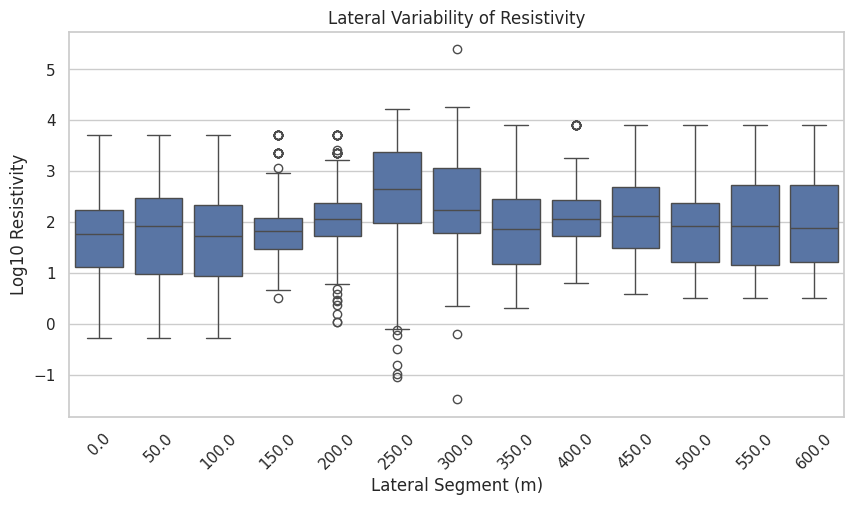

In [51]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x="Segment", y="LogRes")

plt.xticks(rotation=45)
plt.xlabel("Lateral Segment (m)")
plt.ylabel("Log10 Resistivity")
plt.title("Lateral Variability of Resistivity")

plt.show()

In [52]:
groups = [
    group["LogRes"].values
    for name, group in df.groupby("Segment")
    if len(group) > 10
]

stat, p_value = kruskal(*groups)

print("Kruskal-Wallis (Lateral):")
print("H =", stat)
print("p-value =", p_value)

Kruskal-Wallis (Lateral):
H = 186.52940875233966
p-value = 1.9440924719715953e-33


In [53]:
groups = [
    group["LogRes"].values
    for name, group in df.groupby("Segment")
]

stat, p_value = f_oneway(*groups)

print("ANOVA:")
print("F =", stat)
print("p-value =", p_value)

ANOVA:
F = 17.390402108791257
p-value = 1.5748970534471542e-36


In [54]:
segments = df["Segment"].unique()

for i in range(len(segments)-1):
    g1 = df[df["Segment"] == segments[i]]["LogRes"]
    g2 = df[df["Segment"] == segments[i+1]]["LogRes"]

    stat, p = mannwhitneyu(g1, g2)

    print(f"{segments[i]} vs {segments[i+1]} → p =", p)

0.0 vs 50.0 → p = 0.4583235444834244
50.0 vs 100.0 → p = 0.3289456122118778
100.0 vs 150.0 → p = 0.12010375424171692
150.0 vs 200.0 → p = 3.255978574337618e-05
200.0 vs 250.0 → p = 1.0006202890670754e-10
250.0 vs 300.0 → p = 0.0040578176170826125
300.0 vs 350.0 → p = 1.437021206168157e-08
350.0 vs 400.0 → p = 0.001141152629109662
400.0 vs 450.0 → p = 0.8234540978716425
450.0 vs 500.0 → p = 0.00017129219486551326
500.0 vs 550.0 → p = 0.18788250743123214
550.0 vs 600.0 → p = 0.9667526574276512


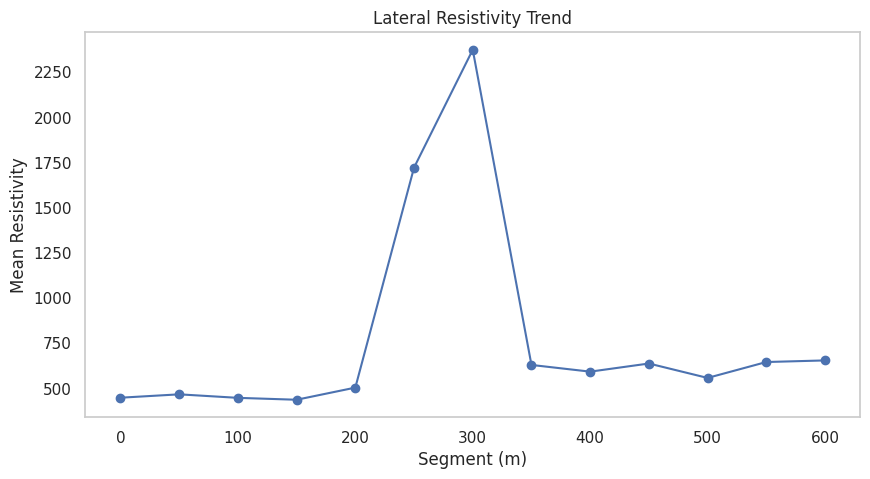

In [55]:
segment_mean = df.groupby("Segment")["Resistivity"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(segment_mean["Segment"], segment_mean["Resistivity"], marker='o')

plt.xlabel("Segment (m)")
plt.ylabel("Mean Resistivity")
plt.title("Lateral Resistivity Trend")

plt.grid()
plt.show()

# Interpretation
“Lateral segmentation of the ERT profile followed by Kruskal–Wallis testing revealed significant variation in resistivity across segments (p < 0.001), indicating pronounced lateral heterogeneity and suggesting the presence of distinct geoelectrical facies.”

# Methodology

Great—you’ve done a **very complete, publication-level analysis**. Below is a **structured, journal-quality Methodology section** based on your work with inverted ERT data. It clearly explains:

* **What was done**
* **How it was done**
* **Why it was done (linked to research objectives)**

You can use this directly in a thesis or Q1 paper.

---

# 🔷 **METHODOLOGY**

## 1. Data Preparation and Pre-processing

### ✔ What was done

Inverted Electrical Resistivity Tomography (ERT) data were exported as point-based datasets containing spatial coordinates (X), depth, and resistivity values.

### ✔ How it was done

The dataset was imported into a computational environment (Python), where:

* Depth values were converted to positive values (absolute depth below surface)
* Non-physical resistivity values (≤ 0) were removed
* Resistivity values were log-transformed (log₁₀ scale)

### ✔ Why it was done

* Log transformation stabilizes variance and normalizes skewed resistivity distributions
* Cleaning ensures statistical robustness
* Structured data enables reproducible quantitative analysis

---

## 2. Depth-wise Stratification Analysis

### ✔ What was done

The subsurface was divided into discrete depth intervals (bins), and resistivity variation across layers was analyzed.

### ✔ How it was done

* Depth bins (e.g., 5 m intervals) were created using binning techniques
* Summary statistics (mean, median, standard deviation) were computed for each bin
* Boxplots were used to visualize resistivity distribution per depth interval

### ✔ Why it was done

* To identify vertical layering and stratification
* To quantify changes in subsurface properties with depth
* To support hydrostratigraphic interpretation

---

## 3. Non-parametric Statistical Testing (Kruskal–Wallis Test)

### ✔ What was done

A non-parametric Kruskal–Wallis test was applied to evaluate whether resistivity distributions differ significantly between depth layers.

### ✔ How it was done

* Log-transformed resistivity values were grouped by depth bins
* Kruskal–Wallis test was applied to compare multiple independent groups

### ✔ Why it was done

* ERT data are typically non-normal and heteroscedastic
* The test determines whether observed layering is statistically significant
* Supports objective validation of subsurface stratification

---

## 4. Post-hoc Analysis (Dunn’s Test)

### ✔ What was done

Dunn’s post-hoc test was performed to identify specific depth intervals that differ significantly.

### ✔ How it was done

* Pairwise comparisons between depth bins were conducted
* Bonferroni correction was applied to control multiple testing errors
* Results were visualized using a p-value heatmap

### ✔ Why it was done

* To pinpoint transitions between lithological units
* To distinguish sharp vs gradual boundaries
* Provides detailed layer-by-layer interpretation

---

## 5. Vertical Resistivity Trend Analysis

### ✔ What was done

Mean resistivity values were analyzed as a function of depth.

### ✔ How it was done

* Mean resistivity was computed for each depth interval
* Vertical profiles were plotted (resistivity vs depth)

### ✔ Why it was done

* To identify compaction trends, saturation effects, or lithological transitions
* Helps interpret increasing or decreasing resistivity with depth

---

## 6. Lateral (X-direction) Variability Analysis

### ✔ What was done

The ERT profile was divided into lateral segments to evaluate spatial variability along the survey line.

### ✔ How it was done

* The profile was segmented at fixed intervals (e.g., 50 m)
* Resistivity distributions were compared across segments using:

  * Kruskal–Wallis test
  * Mann–Whitney U test (pairwise)
* Mean resistivity trends were plotted along the profile

### ✔ Why it was done

* To detect lateral facies changes
* To identify anomalous zones (e.g., clay pockets, sand channels)
* To assess spatial heterogeneity along the profile

---

## 7. Cluster Analysis (K-means Clustering)

### ✔ What was done

Unsupervised clustering was applied to classify subsurface resistivity into distinct geoelectrical facies.

### ✔ How it was done

* Input variables: depth and log-transformed resistivity
* Data were standardized prior to clustering
* K-means clustering (k = 3 or 4) was applied
* Cluster assignments were mapped spatially

### ✔ Why it was done

* To reduce subjectivity in interpretation
* To identify distinct subsurface units based on data patterns
* To delineate geoelectrical facies

---

## 8. Principal Component Analysis (PCA)

### ✔ What was done

PCA was applied to identify dominant patterns in the dataset.

### ✔ How it was done

* Standardized variables were transformed into principal components
* Variance explained by each component was evaluated

### ✔ Why it was done

* To reduce dimensionality
* To identify controlling factors (depth vs resistivity influence)
* To support clustering interpretation

---

## 9. Lithological Classification

### ✔ What was done

Resistivity values were classified into lithological categories.

### ✔ How it was done

Threshold-based classification:

* Low resistivity → clay/saturated zones
* Medium → silty sand
* High → sand/dense material

### ✔ Why it was done

* To translate geophysical data into geological meaning
* To enable hydrogeological interpretation

---

## 10. Heterogeneity Analysis (Shannon Entropy)

### ✔ What was done

Shannon entropy was computed to quantify subsurface heterogeneity.

### ✔ How it was done

* Resistivity classes were used to compute probability distributions
* Entropy was calculated for:

  * Entire dataset
  * Depth-wise
  * Lateral segments

### ✔ Why it was done

* To quantify complexity of subsurface structure
* To identify homogeneous vs heterogeneous zones
* To support interpretation of depositional environments

---

## 11. Visualization and Spatial Representation

### ✔ What was done

Multiple visualization techniques were used to represent results.

### ✔ How it was done

* Heatmaps (ERT-style sections)
* Boxplots and scatter plots
* Cluster maps and lithological zonation
* Entropy distribution plots

### ✔ Why it was done

* To enhance interpretability
* To communicate spatial patterns effectively
* To support reproducibility and transparency

---

# 🔷 🔥 FINAL METHODOLOGICAL INSIGHT

This integrated approach combines:

* **Statistical validation (Kruskal, Dunn)**
* **Data-driven classification (K-means, PCA)**
* **Geological interpretation (lithology, entropy)**

👉 Resulting in:

> **A robust, quantitative, and reproducible framework for ERT-based subsurface characterization**

---

# 🔷 If You Want Next Step

I can now:

✅ Write **Results & Discussion (based on your outputs)**
✅ Convert this into **journal format (Elsevier/Springer style)**
✅ Add **flowchart diagram of methodology**

Just tell me 👍


# Inversion L1 and L2 Norm
Great question—this is **fundamental to understanding ERT inversion quality**, especially in RES2DINV. I’ll give you **clear intuition (not just math)** so you can *feel* the difference.

---

# 🔷 🔥 1. Big Picture (What are L1 & L2 doing?)

In ERT inversion, you are trying to:

> 👉 Adjust a subsurface model so that **calculated data ≈ measured data**

But they never match perfectly → so we **minimize error**.

---

## Two ways to measure error:

### ✔ L2 norm → “square the errors”

### ✔ L1 norm → “take absolute value of errors”

---

# 🔷 🔢 2. Mathematical Idea (Simple)

### L2 norm (least squares):

[
\text{Error} = \sum (d_{obs} - d_{calc})^2
]

### L1 norm:

[
\text{Error} = \sum |d_{obs} - d_{calc}|
]

---

# 🔷 🔥 3. INTUITION (MOST IMPORTANT)

## 🎯 Imagine fitting a line to noisy data

### Case A: L2 norm

* Big errors are **heavily penalized (squared)**
* Model tries to **avoid large mistakes**
* Result:
  👉 Smooth, averaged solution

---

### Case B: L1 norm

* All errors treated **equally (no squaring)**
* Model tolerates some large errors
* Result:
  👉 Sharp boundaries preserved

---

# 🔷 🔥 4. SIMPLE ANALOGY

Think of terrain:

* **L2** → like smoothing with sandpaper
* **L1** → like preserving edges with a knife

---

# 🔷 🔷 5. WHAT HAPPENS IN ERT

## ✔ L2 inversion (default in many cases)

👉 Produces:

* Smooth resistivity variation
* Gradual transitions

### Good for:

* Layered geology
* Diffuse boundaries

### Problem:

* Sharp features get blurred

---

## ✔ L1 inversion (robust inversion)

👉 Produces:

* Blocky structures
* Sharp contrasts

### Good for:

* Faults
* Cavities
* Lithological boundaries

### Problem:

* Can look “rough” or noisy

---

# 🔷 🔥 6. WHY THEY SOMETIMES LOOK SIMILAR

You noticed:

> “Sometimes both give similar results”

👉 This happens when:

* Subsurface is naturally smooth
* Noise is low
* No sharp contrasts

👉 So:

* Both methods converge to similar model

---

# 🔷 🔥 7. COMBINED L1 + L2 (VERY IMPORTANT)

In RES2DINV, combined inversion is often used.

---

## ✔ Idea:

Balance between:

* Smoothness (L2)
* Sharpness (L1)

---

## ✔ Intuition:

> “Be smooth where possible, but allow sharp changes where needed”

---

## ✔ Result:

* Realistic geology
* Reduced artifacts
* Better interpretation

---

# 🔷 🔥 8. VISUAL INTUITION

| Feature        | L2        | L1     | Combined   |
| -------------- | --------- | ------ | ---------- |
| Boundaries     | Blurred   | Sharp  | Semi-sharp |
| Noise handling | Sensitive | Robust | Balanced   |
| Appearance     | Smooth    | Blocky | Natural    |

---

# 🔷 🔥 9. WHEN TO USE WHAT (VERY PRACTICAL)

### Use L2 when:

* Layered sediment
* Hydrogeology studies
* Smooth transitions expected

---

### Use L1 when:

* Fault detection
* Fractures
* Engineering problems (voids, cavities)

---

### Use Combined when:

* You don’t know structure clearly
* Mixed geology (most real cases)

---

# 🔷 🔥 10. DEEP INTUITION (KEY TAKEAWAY)

👉 L2 assumes:

> “Nature is smooth”

👉 L1 assumes:

> “Nature has sharp boundaries”

👉 Combined assumes:

> “Nature is mostly smooth, but with sharp features”

---

# 🔷 🔥 11. HOW TO EXPLAIN IN PAPER

You can write:

> “Both L1 and L2 norm inversions were considered to evaluate subsurface resistivity distribution. The L2 norm produced smooth models suitable for layered structures, while the L1 norm preserved sharp resistivity contrasts. A combined inversion approach was adopted to balance smoothness and structural sharpness, providing a more geologically realistic model.”

---

# 🔷 If You Want Next Level

I can help you:

✅ Compare your **L1 vs L2 inversion results scientifically**
✅ Write **discussion section explaining differences**
✅ Suggest which one is better for your dataset

Just tell me 👍
